In [ ]:
# %% Imports and config
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import torch
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import copy
import re
from sklearn.metrics import mean_absolute_error, mean_squared_error


# --- CONFIG ---
BATCH_SIZE = 256
EPOCHS = 75
LEARNING_RATE = 1e-5
KFOLDS = 2
TEST_SPLIT = 0.2
SEED = 2222

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [496]:
class TimeSeriesDataset(Dataset):
    def __init__(self, csv_files, step=1, input_range=(-1, 1), target_range=(-1, 1), value_clip=1e5, lower_limit=10000, upper_limit=10000):
        self.data = []
        self.target = []

        print(f"📂 Processing {len(csv_files)} files")
        if (isinstance(csv_files, list) and not csv_files) or \
        (hasattr(csv_files, "empty") and csv_files.empty):
            raise ValueError("❌ No CSV files provided.")


        for file in csv_files:
            try:
                df = pd.read_csv(file).iloc[lower_limit:upper_limit:step]

                for phase in ['A', 'B', 'C']:
                    I   = df[f'I{phase.lower()}'].values
                    top = df[f'top{phase}'].values
                    bot = df[f'bot{phase}'].values
                    L   = df[f'L{phase.lower()}_value'].values
                    C   = df[f'C{phase.lower()}_value'].values
                    Lg  = df[f'L{phase.lower()}g_value'].values
                    next_I = df[f'I{phase.lower()}_next_value'].values
                    time_step = df['time_step'].values
                    Vin = df['Vin_value'].values  # <-- Dodato

                    top = (top > 0.5).astype(float)
                    bot = (bot > 0.5).astype(float)

                    valid_mask = (
                        np.isfinite(I) & np.isfinite(top) & np.isfinite(bot) &
                        np.isfinite(L) & np.isfinite(C) & np.isfinite(Lg) &
                        np.isfinite(next_I) & np.isfinite(time_step) & np.isfinite(Vin) &
                        (np.abs(I) < value_clip) & (np.abs(next_I) < value_clip)
                    )

                    if not np.any(valid_mask):
                        print(f"⚠️ Skipping {file} phase {phase}: no valid data")
                        continue

                    I = I[valid_mask]
                    top = top[valid_mask]
                    bot = bot[valid_mask]
                    L = L[valid_mask]
                    C = C[valid_mask]
                    Lg = Lg[valid_mask]
                    time_step = time_step[valid_mask]
                    Vin = Vin[valid_mask]
                    next_I = next_I[valid_mask]

                    inputs = np.stack([I, top, bot, L, C, Lg, time_step, Vin], axis=1)  # <-- Vin dodat
                    self.data.append(inputs)
                    self.target.append(next_I)

            except Exception as e:
                print(f"❌ Failed to process {file}: {e}")
                continue

        self.data = np.concatenate(self.data, axis=0)
        self.target = np.concatenate(self.target, axis=0)

        self.scaler_X = MinMaxScaler(feature_range=input_range)
        self.scaler_y = MinMaxScaler(feature_range=target_range)

        self.data = self.scaler_X.fit_transform(self.data)
        self.target = self.scaler_y.fit_transform(self.target.reshape(-1, 1)).flatten()

        print(f"✅ Loaded {len(self.data)} samples from {len(csv_files)} files.")
        print(f"📊 Input shape: {self.data.shape}, Target shape: {self.target.shape}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.data[idx], dtype=torch.float32),
            torch.tensor(self.target[idx], dtype=torch.float32)
        )

    def get_scalers(self):
        return self.scaler_X, self.scaler_y


In [497]:
class SinCosActivation(nn.Module):
    def __init__(self, alpha=1.0, beta = 1.0, gamma = 1.0, delta = 1.0, epsilon = 0):
        super().__init__()
        self.alpha   = nn.Parameter(torch.tensor(alpha, dtype=torch.float32))
        self.beta    = nn.Parameter(torch.tensor(beta, dtype=torch.float32))
        self.gamma   = nn.Parameter(torch.tensor(gamma, dtype=torch.float32))
        self.delta   = nn.Parameter(torch.tensor(delta, dtype=torch.float32))
        self.epsilon = nn.Parameter(torch.tensor(epsilon, dtype=torch.float32))
    def forward(self, x):
        return ((self.delta * (torch.sin(self.alpha )) + (torch.cos(self.beta )) * self.gamma)  + self.epsilon) * x


In [498]:
class FeedforwardNet(nn.Module):
    def __init__(self, input_size=8, hidden_layers=7, neurons_per_layer=64, output_size=1, dropout_rate=0.1):
        super().__init__()

        layers = []
        prev_size = input_size

        for _ in range(hidden_layers):
            layers.append(nn.Linear(prev_size, neurons_per_layer))
            layers.append(SinCosActivation())
            layers.append(nn.Dropout(dropout_rate))  # ← dodat dropout
            prev_size = neurons_per_layer

        layers.append(nn.Linear(prev_size, output_size))
        self.model = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.model(x)

In [499]:
def physics_loss(pred, inputs, V_DC=0.5):
    # inputs: [I, top, bot, L, C, Lg, dt, Vin]
    I   = inputs[:, 0]
    top = inputs[:, 1]
    bot = inputs[:, 2]
    L   = inputs[:, 3]
    C   = inputs[:, 4]
    Lg  = inputs[:, 5]
    dt  = inputs[:, 6]
    Vin = inputs[:, 7]  # ako koristiš dinamički Vin iz CSV

    # V_inv kao funkcija top/bot i Vin
    V_inv = Vin * (top - bot)

    dI_dt = (pred.squeeze() - I) / dt
    dI_dt =  torch.clamp(dI_dt, -1e3, 1e3)  # smoother clamp

    # Prva fizička relacija: V_inv = L * dI + V_C
    V_C_est = V_inv - L * dI_dt

    # Pretpostavi da V_C se ne menja značajno u jednom koraku (za gubitak)
    dV_C = (V_C_est - V_C_est.detach())
    I_C_expected = C * dV_C / dt

    loss_inductor = (V_inv - (L * dI_dt + V_C_est.detach())) ** 2
    loss_capacitor = (I - I_C_expected) ** 2

    return torch.mean(loss_inductor + 0.1 * loss_capacitor)


In [500]:
def energy_loss(pred, target, inputs):
    # inputs: [I_t, top, bot, L, C, Lg, dt, Vin]
    I_t  = inputs[:, 0]
    top  = inputs[:, 1]
    bot  = inputs[:, 2]
    L    = inputs[:, 3]
    C    = inputs[:, 4]
    Lg   = inputs[:, 5]
    dt   = inputs[:, 6]
    Vin  = inputs[:, 7]

    # Pretpostavljamo da je izlaz predikcije I_t+1
    I_tp1 = pred.squeeze()

    # Ulazna energija – P_in * dt
    V_inv = Vin * (top - bot)
    E_in = V_inv * I_t * dt

    # Energija u L i Lg komponentama na t i t+1
    E_L_old = 0.5 * (L + Lg) * I_t**2
    E_L_new = 0.5 * (L + Lg) * I_tp1**2

    # Rekonstruiši V_C(t+1) ≈ V_inv - V_L
    dI = (I_tp1 - I_t) / dt
    dI = 1e3 * torch.tanh(dI / 1e3)  # stabilna verzija

    V_L = (L + Lg) * dI
    V_C_tp1 = V_inv - V_L
    E_C_new = 0.5 * C * V_C_tp1**2

    # Očekivana ukupna nova energija
    E_stored = E_L_new + E_C_new

    # Očuvanje energije
    energy_balance_error = (E_in - (E_stored - E_L_old))**2

    return energy_balance_error.mean()


In [501]:
def peak_trough_loss(y_pred, y_true):
    peak_diff   = torch.abs(y_pred.max() - y_true.max())
    trough_diff = torch.abs(y_pred.min() - y_true.min())
    return (peak_diff + trough_diff)

In [ ]:
import torch, torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from collections import defaultdict
from tqdm.auto import tqdm
import numpy as np

# ─────────────────────────────────────────────────────────────────────

def _compute_components(pred, target, inputs, λ_phys=0.0, λ_energy=0.0):
    mse = F.huber_loss(pred.squeeze(), target, reduction="sum")
    pt = peak_trough_loss(pred, target)
    
    shape = pt * λ_energy  # optionally disable for now

    raw_phys = physics_loss(pred, inputs)
    raw_el = energy_loss(pred, target, inputs)

    # Normalize physics/power to prevent overpowering
    norm_phys = raw_phys
    norm_el   = raw_el 


    phys = λ_phys * norm_phys
    power = 0 * λ_energy * norm_el

    total = mse + shape + phys + power
    return total, mse, shape, phys, power


# ──────────────────────────────────────────────────────────────

def train_fold(
    model,
    train_loader,
    val_loader,
    *,
    n_epochs: int = EPOCHS,
    lr: float = 3e-4,
    weight_decay: float = 1e-3,
    clip_grad: float = 1.0,
    patience: int = 10,
    delay_epochs: int = 15,
    device: torch.device = None
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.25, patience=4, min_lr=1e-8, verbose=True
    )

    best_val, best_sd, stall = float("inf"), None, 0
    history = defaultdict(list)

    λ_phys_levels = np.logspace(np.log10(8e-3), np.log10(1.0), num=7)
    λ_energy_levels = np.logspace(np.log10(8e-3), np.log10(1.0), num=7)

    stage_phys, stage_energy = 0, 0
    min_phys_loss, min_energy_loss = float("inf"), float("inf")
    phys_stall, energy_stall = 0, 0
    phys_improve_streak = 0
    energy_improve_streak = 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        sums = defaultdict(float)

        λ_phys_now = float(λ_phys_levels[stage_phys])
        λ_energy_now = float(λ_energy_levels[stage_energy])

        for X, y in tqdm(train_loader, desc=f"Epoch {epoch:02d}", leave=False):
            X, y = X.to(device), y.to(device)
            opt.zero_grad()

            def closure():
                opt.zero_grad()
                y_hat = model(X)
                total, mse, shape, phys, el = _compute_components(y_hat, y, X, λ_phys_now, λ_energy_now)
                total.backward()
                return total

            if isinstance(opt, torch.optim.LBFGS):
                total = closure()  # Needed to track loss in history
                grad_norm = clip_grad_norm_(model.parameters(), clip_grad).item()
                opt.step(closure)
            else:
                y_hat = model(X)
                total, mse, shape, phys, el = _compute_components(y_hat, y, X, λ_phys_now, λ_energy_now)
                total.backward()
                grad_norm = clip_grad_norm_(model.parameters(), clip_grad).item()
                opt.step()

            bsz = X.size(0)
            sums["total"] += total.item() * bsz
            sums["mse"] += mse.item() * bsz
            sums["shape"] += shape.item() * bsz
            sums["phys"] += phys.item() * bsz
            sums["pow"] += el.item() * bsz
            sums["grad"] += grad_norm * bsz


        n_train = len(train_loader.dataset)
        history["train_total"].append(sums["total"] / n_train)
        history["train_mse"].append(sums["mse"] / n_train)
        history["train_shape"].append(sums["shape"] / n_train)
        history["train_phys"].append(sums["phys"] / n_train)
        history["train_pow"].append(sums["pow"] / n_train)
        history["grad_norm"].append(sums["grad"] / n_train)
        history["lr"].append(opt.param_groups[0]["lr"])
        history["stage_phys"].append(stage_phys)
        history["stage_energy"].append(stage_energy)

        model.eval()
        with torch.no_grad():
            sums = defaultdict(float)
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                total, mse, shape, phys, el = _compute_components(y_hat, y, X, λ_phys_now, λ_energy_now)
                bsz = X.size(0)
                sums["total"] += total.item() * bsz
                sums["mse"] += mse.item() * bsz
                sums["shape"] += shape.item() * bsz
                sums["pow"] += el.item() * bsz
                sums["phys"] += phys.item() * bsz

        n_val = len(val_loader.dataset)
        val_metric = sums["total"] / n_val
        val_phys_loss = sums["phys"] / n_val
        val_energy_loss = sums["pow"] / n_val

        history["val_total"].append(val_metric)
        history["val_mse"].append(sums["mse"] / n_val)
        history["val_shape"].append(sums["shape"] / n_val)
        history["val_phys"].append(val_phys_loss)
        history["val_pow"].append(val_energy_loss)

        # Adaptive lambda stage logic
               # Adaptive lambda stage logic — poboljšana logika sa prozorom poslednjih 5 epoha
               # Adaptive lambda stage logic — čekanje 3 uzastopna napretka

        if val_phys_loss < min_phys_loss - 1e-5:
            min_phys_loss = val_phys_loss
            phys_stall = 0
            phys_improve_streak += 1
        else:
            phys_stall += 1
            phys_improve_streak = 0

        if phys_stall == 0 and phys_improve_streak >= 2 and stage_phys + 1 < len(λ_phys_levels):
            stage_phys += 1
            phys_improve_streak = 0

        if val_energy_loss < min_energy_loss - 1e-5:
            min_energy_loss = val_energy_loss
            energy_stall = 0
            energy_improve_streak += 1
        else:
            energy_stall += 1
            energy_improve_streak = 0

        if energy_stall == 0 and energy_improve_streak >= 2 and stage_energy + 1 < len(λ_energy_levels):
            stage_energy += 1
            energy_improve_streak = 0

        scheduler.step(val_metric)

        if val_metric < best_val - 1e-5:
            best_val, best_sd = val_metric, model.state_dict()
            stall = 0
        else:
            stall += 1

        if epoch > delay_epochs and stall >= patience:
            print("🔁 Resetting LR after plateau...")
            for g in opt.param_groups:
                g['lr'] = lr
            stall = 0

        if epoch % 8 == 0 and stage_phys + 1 < len(λ_phys_levels):
            stage_phys += 1
        
        last_lr = opt.param_groups[0]["lr"]

        # Assume model is already trained for N epochs with AdamW
        if epoch % 35 == 0:
            opt = torch.optim.SGD(model.parameters(), lr=last_lr, momentum=0.9, weight_decay=1e-5)

        

            
        print(f"Epoch {epoch:02d} | T {history['train_total'][-1]:.6f} | V {val_metric:.6f} | "
              f"LR {history['lr'][-1]:.2e} | ‖∇‖ {history['grad_norm'][-1]:.3f} | "
              f"λ_phys {float(λ_phys_levels[stage_phys]):.3e}, λ_en {float(λ_energy_levels[stage_energy]):.3e}")

        print(f"     └── Train MSE: {history['train_mse'][-1]:.6f}, Shape: {history['train_shape'][-1]:.6f}, "
              f"Phys: {history['train_phys'][-1]:.6f}, Pow: {history['train_pow'][-1]:.6f}")
        print(f"     └── Val   MSE: {history['val_mse'][-1]:.6f}, Shape: {history['val_shape'][-1]:.6f}, "
              f"Phys: {val_phys_loss:.6f}, Pow: {val_energy_loss:.6f}")

    return best_sd, best_val, history, model


In [503]:
def cross_validate(
        dataset,
        hidden_layers: int      = 6,
        neurons_per_layer: int  = 256,
        input_size: int         = 5,
        *,
        n_epochs: int           = EPOCHS,
        lr: float               = 3e-4,
        λ_phys: float           = 1.0,
        weight_decay: float     = 1e-4,
        clip_grad: float        = 1.0,
        delay_epochs=15,
        dropout = 0.2
):
    
    """
    K-fold CV wrapper oko nove train_fold().
    Vraća:
        best_state_dict         – parametri modela sa najmanjim val-loss-om
        test_set                – desetak % podataka za finalno testiranje
        all_histories           – lista dict-ova (po jedan po fold-u) sa
                                  kolonama train_total, val_total, lr, grad_norm …
        best_model              – instanca FeedforwardNet sa best_state_dict
    """
    
    # ――― Split to test + train/val ―――
    indices   = np.arange(len(dataset))
    np.random.shuffle(indices)
    test_size = int(TEST_SPLIT * len(indices))
    test_set  = Subset(dataset, indices[:test_size])
    train_val = Subset(dataset, indices[test_size:])

    kfold  = KFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)

    all_histories      = []
    best_state_dict    = None
    best_model         = None
    best_val_overall   = float("inf")

    for fold, (tr_idx, va_idx) in enumerate(kfold.split(range(len(train_val)))):
        print(f"\n――― Fold {fold+1} / {KFOLDS} ―――")

        tr_loader = DataLoader(
            Subset(train_val, tr_idx), batch_size=BATCH_SIZE, shuffle=True
        )
        va_loader = DataLoader(
            Subset(train_val, va_idx), batch_size=BATCH_SIZE
        )

        model = FeedforwardNet(
            input_size=input_size,
            hidden_layers=hidden_layers,
            neurons_per_layer=neurons_per_layer, 
            dropout_rate = dropout
        ).to(device)

        best_sd_fold, best_val_fold, hist_fold, _ = train_fold(
            model, tr_loader, va_loader,
            n_epochs=n_epochs, lr=lr,
            weight_decay=weight_decay, clip_grad=clip_grad,
            device=device, delay_epochs=delay_epochs
        )

        all_histories.append(hist_fold)

        # zadržavamo globalno najbolji model
        if best_val_fold < best_val_overall:
            best_val_overall = best_val_fold
            best_state_dict  = best_sd_fold
            best_model       = model
            best_model.load_state_dict(best_state_dict)   # sinhronizuj

        print(f"▶︎  Fold-{fold+1} best val = {best_val_fold:.6f}")

    return best_state_dict, test_set, all_histories, best_model, model


In [504]:
def plot_avg_loss_curves(train_losses, val_losses):
    max_len = max(len(t) for t in train_losses)

    def pad_with_nan(lst, target_len):
        return lst + [np.nan] * (target_len - len(lst))

    padded_train = np.array([pad_with_nan(t, max_len) for t in train_losses])
    padded_val = np.array([pad_with_nan(v, max_len) for v in val_losses])

    avg_train = np.nanmean(padded_train, axis=0)
    avg_val = np.nanmean(padded_val, axis=0)

    plt.figure(figsize=(10, 5))
    plt.plot(avg_train, label="Avg Train Loss")
    plt.plot(avg_val, label="Avg Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Cross-Validation Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()


In [505]:
import re
import pandas as pd

def filter_file_list_by_ranges(raw_data, L_range, C_range, Lg_range, Vin_range):
    pattern = re.compile(
        r"L=(?P<L>[\de\+\-\.]+)_C=(?P<C>[\de\+\-\.]+)_Lg=(?P<Lg>[\de\+\-\.]+)_V=(?P<Vin>[\de\+\-\.]+)"
    )

    entries = []
    for line in raw_data.strip().splitlines():
        line = line.strip()
        if not line:
            continue
        match = pattern.search(line)
        if match:
            L   = float(match.group("L"))
            C   = float(match.group("C"))
            Lg  = float(match.group("Lg"))
            Vin = float(match.group("Vin"))
            if (L_range[0] <= L <= L_range[1] and
                C_range[0] <= C <= C_range[1] and
                Lg_range[0] <= Lg <= Lg_range[1] and
                Vin_range[0] <= Vin <= Vin_range[1]):
                entries.append({
                    "file": line,
                    "L": L, "C": C, "Lg": Lg, "Vin": Vin
                })

    return pd.DataFrame(entries)


In [506]:
if __name__ == "__main__":
    # Try different file name patterns - adjust this based on your actual file names
    patterns = ["new*""*"]
    
    for pattern in patterns:
        base = pattern.split("*")[0]
        csv_files = [f for f in os.listdir() if f.endswith(".csv") and f.startswith("new") 
                     and (              f.endswith("_time_step_5e-07.csv")
                                     #or f.endswith("_time_step_2e-06.csv")
                                     #or f.endswith("_time_step_5e-06.csv")
                                     #or f.endswith("_time_step_7e-06.csv")
                                     #or f.endswith("_time_step_1e-05.csv")
                                     )]
        if csv_files:
            print(f"Found {len(csv_files)} files with pattern '{pattern}'")
            break
    
    if not csv_files:
        print("No CSV files found. Please check your directory.")
        # List all files in directory for debugging
        print("Files in directory:", os.listdir())
        exit(1)


    raw_data = """ 
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=5e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=1e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=1e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=1e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=1e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=1e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=2e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=2e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=2e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=2e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=2e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=3e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=3e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=3e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=3e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=3e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=4e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=4e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=4e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=4e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=4e+02_time_step_7e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=5e+02_time_step_1e-05.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=5e+02_time_step_2e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=5e+02_time_step_5e-06.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=5e+02_time_step_5e-07.csv
        new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=5e+02_time_step_7e-06.csv
    """
    

    # Pakuje sve redove u listu stringova
    df_filtered = filter_file_list_by_ranges(
        raw_data  = raw_data,
        L_range   = (1e-5, 5e-3),
        C_range   = (1e-5, 5e-3),
        Lg_range  = (1e-5, 5e-3),
        Vin_range = (100 , 500 )
    )

    #print(df_filtered.head())
    
    csv_files = [f for f in csv_files if f in set(df_filtered['file'])]


    # Create dataset
    #dataset = TimeSeriesDataset(csv_files, lower_limit=2050, upper_limit=2550)
    

Found 500 files with pattern 'new**'


In [525]:
print(csv_files)
file_names = csv_files
# After cross-validation
input_size, hidden_layers, neurons_per_layer, output_size = 8, 7, 128, 1
print("input_size:", input_size)
print("hidden_layers:", hidden_layers)
print("neurons_per_layer:", neurons_per_layer)
print("output_size:", output_size)
plt.style.use("default")
best_model_state_dict, test_set, train_losses, val_losses, model = cross_validate(dataset, input_size= input_size, hidden_layers=hidden_layers, neurons_per_layer=neurons_per_layer, dropout=0)


['new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-07.csv', 'new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-07.csv', 'new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-07.csv', 'new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-07.csv', 'new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-07.csv', 'new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-07.csv', 'new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-07.csv', 'new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-07.csv', 'new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-07.csv', 'new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-07.csv', 'new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-07.csv', 'new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-07.csv', 'new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-07.csv', 'new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-07.csv', 'new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=5e+02_t

C:\Users\OgnjenPeric\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01:   0%|          | 0/305 [00:00<?, ?it/s]

Epoch 01 | T 6.595568 | V 0.074172 | LR 3.00e-04 | ‖∇‖ 746.650 | λ_phys 8.000e-03, λ_en 8.000e-03
     └── Train MSE: 6.592872, Shape: 0.002692, Phys: 0.000003, Pow: 0.000000
     └── Val   MSE: 0.073444, Shape: 0.000725, Phys: 0.000003, Pow: 0.000000


Epoch 02:   0%|          | 0/305 [00:00<?, ?it/s]

...

Epoch 53 | T 0.006015 | V 0.006740 | LR 3.00e-04 | ‖∇‖ 0.309 | λ_phys 1.000e+00, λ_en 8.000e-03
     └── Train MSE: 0.000155, Shape: 0.000027, Phys: 0.000291, Pow: 0.000000
     └── Val   MSE: 0.005827, Shape: 0.000532, Phys: 0.000381, Pow: 0.000000


Epoch 54:   0%|          | 0/305 [00:00<?, ?it/s]

Epoch 54 | T 0.006024 | V 0.006740 | LR 3.00e-04 | ‖∇‖ 0.307 | λ_phys 1.000e+00, λ_en 8.000e-03
     └── Train MSE: 0.000155, Shape: 0.000027, Phys: 0.000291, Pow: 0.000000
     └── Val   MSE: 0.005827, Shape: 0.000532, Phys: 0.000381, Pow: 0.000000


Epoch 55:   0%|          | 0/305 [00:00<?, ?it/s]

Epoch 55 | T 0.006032 | V 0.006740 | LR 3.00e-04 | ‖∇‖ 0.303 | λ_phys 1.000e+00, λ_en 8.000e-03
     └── Train MSE: 0.000155, Shape: 0.000027, Phys: 0.000291, Pow: 0.000000
     └── Val   MSE: 0.005827, Shape: 0.000532, Phys: 0.000381, Pow: 0.000000
▶︎  Fold-2 best val = 0.006355


In [524]:
# Initialize a new model object with the correct input size
#model = FeedforwardNet(input_size=input_size, output_size=output_size, hidden_layers=hidden_layers, neurons_per_layer=neurons_per_layer).to(device)

# Load the best model's state dictionary into the model
model.load_state_dict(best_model_state_dict)
name = f"1ph_inv_model_LCL_h{hidden_layers}w{neurons_per_layer}_dt=5e-7_limited_data_no_dropout.pth"
# Save the model
torch.save(model.state_dict(), name)
print(f"\n✅ Model saved as '1ph_inv_model_LCL_h{hidden_layers}w{neurons_per_layer}_dt=5e-7_limited_data_no_dropout.pth'")

# Evaluate and visualize the results
#plot_avg_loss_curves(train_losses, val_losses)



✅ Model saved as '1ph_inv_model_LCL_h7w128_dt=5e-7_limited_data_no_dropout.pth'


In [509]:
def plot_training_history_single(history, show_lr=True):
    
    plt.style.use("light_background")

    epochs = np.arange(1, len(history["train_total"]) + 1)

    # --- Glavni lossovi ---
    plt.figure(figsize=(12, 6))
    plt.plot(epochs, history["train_total"], label="Train Total")
    plt.plot(epochs, history["val_total"], label="Val Total")
    plt.plot(epochs, history["train_mse"], label="Train MSE")
    plt.plot(epochs, history["val_mse"], label="Val MSE")
    plt.plot(epochs, history["train_phys"], label="Train Phys")
    plt.plot(epochs, history["train_shape"], label="Train Shape")
    plt.plot(epochs, history["val_shape"], label="Val Shape")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Components per Epoch")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Learning rate & gradient norm ---
    if show_lr:
        fig, ax1 = plt.subplots(figsize=(12, 4))

        ax1.plot(epochs, history["lr"], label="LR", color="tab:blue")
        ax1.set_ylabel("Learning Rate", color="tab:blue")
        ax1.tick_params(axis='y', labelcolor="tab:blue")

        ax2 = ax1.twinx()
        ax2.plot(epochs, history["grad_norm"], label="‖∇‖", color="tab:red")
        ax2.set_ylabel("Gradient Norm", color="tab:red")
        ax2.tick_params(axis='y', labelcolor="tab:red")

        plt.title("Learning Rate & Gradient Norm per Epoch")
        plt.grid(True)
        plt.tight_layout()
        plt.show()


In [510]:
import pandas as pd

def histories_to_df(H_list):
    """K -> pandas DF sa kolonama + fold + epoch."""
    rows = []
    for i, h in enumerate(H_list, 1):                 # i = fold id
        df = pd.DataFrame(h)                          # svaka kolona je lista
        df["epoch"] = df.index + 1
        df["fold"]  = i
        rows.append(df)
    return pd.concat(rows, ignore_index=True)

hist_df = histories_to_df(train_losses)
display(hist_df.head())


,train_total,train_mse,train_shape,train_phys,train_pow,grad_norm,lr,stage_phys,stage_energy,val_total,val_mse,val_shape,val_phys,val_pow,epoch,fold
0,16.066835,16.061817,0.005016,0.000003,0.0,1249.964412,0.0003,0,0,0.162156,0.161402,0.000752,0.000003,0.0,1,1
1,0.178194,0.177418,0.000773,0.000003,0.0,100.240659,0.0003,0,0,0.028394,0.027776,0.000615,0.000003,0.0,2,1
2,0.025364,0.024775,0.000586,0.000003,0.0,12.001710,0.0003,0,0,0.010297,0.009742,0.000553,0.000003,0.0,3,1
3,0.011259,0.010712,0.000545,0.000003,0.0,3.781128,0.0003,0,0,0.008205,0.007679,0.000523,0.000003,0.0,4,1
4,0.009968,0.009421,0.000544,0.000003,0.0,2.734071,0.0003,0,0,0.012284,0.011742,0.000539,0.000003,0.0,5,1


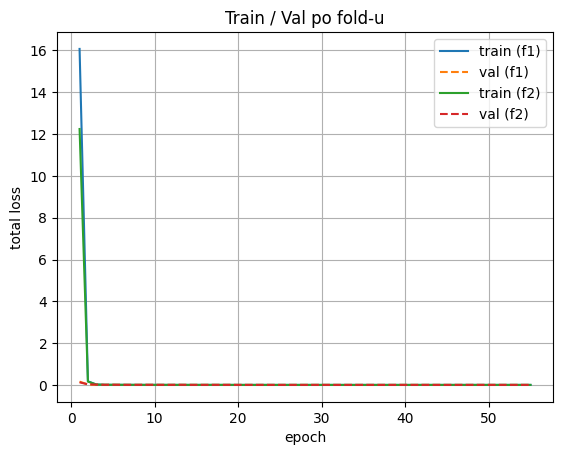

In [511]:
import matplotlib.pyplot as plt

for f, g in hist_df.groupby("fold"):
    plt.plot(g["epoch"], g["train_total"], label=f"train (f{f})")
    plt.plot(g["epoch"], g["val_total"],   label=f"val (f{f})", linestyle="--")

plt.xlabel("epoch");  plt.ylabel("total loss")
plt.title("Train / Val po fold-u")
plt.legend();  plt.grid(True);  plt.show()


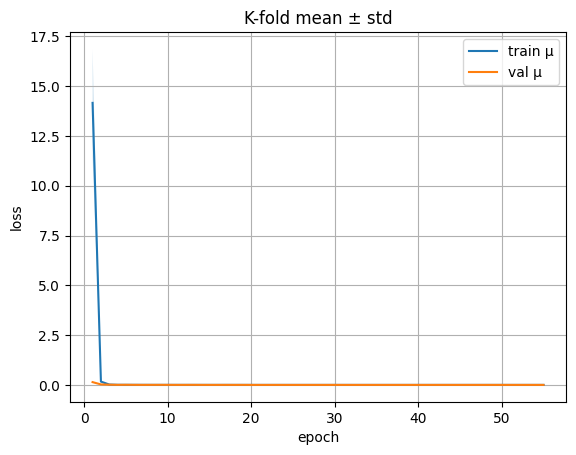

In [512]:
import numpy as np

pivot_tr = hist_df.pivot(index="epoch", columns="fold", values="train_total")
pivot_va = hist_df.pivot(index="epoch", columns="fold", values="val_total")

μ_tr, σ_tr = pivot_tr.mean(axis=1), pivot_tr.std(axis=1)
μ_va, σ_va = pivot_va.mean(axis=1), pivot_va.std(axis=1)

plt.plot(μ_tr.index, μ_tr, label="train μ")
plt.fill_between(μ_tr.index, μ_tr-σ_tr, μ_tr+σ_tr, alpha=0.2)

plt.plot(μ_va.index, μ_va, label="val μ")
plt.fill_between(μ_va.index, μ_va-σ_va, μ_va+σ_va, alpha=0.2)

plt.xlabel("epoch");  plt.ylabel("loss")
plt.title("K-fold mean ± std")
plt.legend();  plt.grid(True);  plt.show()


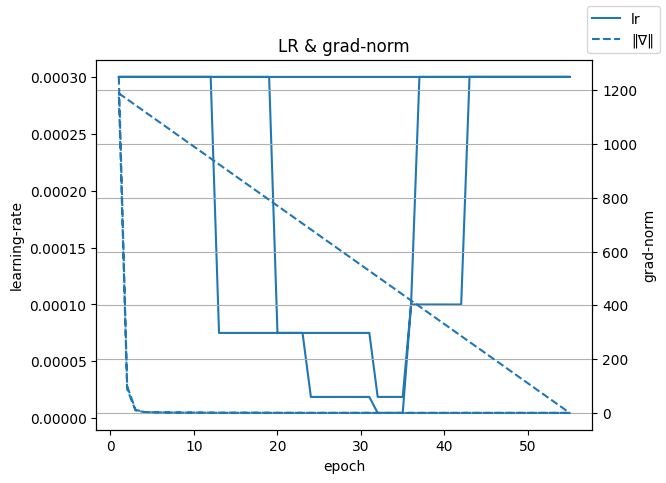

In [513]:
fig, ax1 = plt.subplots()

ax1.plot(hist_df["epoch"], hist_df["lr"],  label="lr")
ax1.set_xlabel("epoch");  ax1.set_ylabel("learning-rate")

ax2 = ax1.twinx()
ax2.plot(hist_df["epoch"], hist_df["grad_norm"], label="‖∇‖", linestyle="--")
ax2.set_ylabel("grad-norm")
fig.legend(loc="upper right");  plt.title("LR & grad-norm");  plt.grid(True);  plt.show()


In [514]:
import matplotlib.pyplot as plt
import torch
import pandas as pd
import numpy as np
import re
from sklearn.metrics import mean_absolute_error

def rolling_mean(arr, window=250):
    """Simple moving average."""
    return np.convolve(arr, np.ones(window)/window, mode='same')

def plot_prediction_vs_truth_1model_multi_phase(
    csv_path,
    model,
    name,
    scaler_X,
    scaler_y,
    hidden_layers,
    neurons_per_layer,
    start_time,
    end_time,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    phases_to_display = [0, 1, 2],
    smooth = False,
    window_size = 200
):
    model.load_state_dict(torch.load(name, map_location=device))
    model.to(device)
    model.eval()

    # === Extract all LC parameters from filename
    param_names = ['L', 'C', 'Lg', 'V']
    pattern = r'(?P<name>' + '|'.join(param_names) + r')=(?P<val>[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)'
    matches = re.findall(pattern, csv_path)
    param_values = {name: float(val) for name, val in matches}
    param_text = ", ".join([f"{k}={v:.0e}" for k, v in param_values.items()])

    df = pd.read_csv(csv_path)

    # === Inputs and Targets ===
    inputs_per_phase = {}
    for idx, phase in enumerate(['a', 'b', 'c']):
        I   = df[f'I{phase}'].values
        top = (df[f'top{phase.upper()}'].values > 0.5).astype(float)
        bot = (df[f'bot{phase.upper()}'].values > 0.5).astype(float)
        L   = df[f'L{phase}_value'].values
        C   = df[f'C{phase}_value'].values
        Lg  = df[f'L{phase}g_value'].values
        dt  = df['time_step'].values
        Vin = df["Vin_value"].values 
        inputs = np.stack([I, top, bot, L, C, Lg, dt, Vin], axis=1)
        inputs = scaler_X.transform(inputs)  # normalize
        inputs_per_phase[idx] = inputs.astype(np.float32)

    targets = df[['Ia_next_value', 'Ib_next_value', 'Ic_next_value']].values.astype(np.float32)
    next_time = df["time"].values + df["time_step"].values
    step = df["time_step"].values
    
    # === Prediction per phase ===
    preds = []
    for idx in phases_to_display:
        X = torch.tensor(inputs_per_phase[idx], dtype=torch.float32).to(device)
        with torch.no_grad():
            y_pred = model(X).cpu().numpy()
        y_pred_denorm = scaler_y.inverse_transform(y_pred)
        preds.append(y_pred_denorm)

    # === Stack predictions and ground truth
    y_pred_denorm_all = np.hstack(preds)
    y_true_denorm = targets

    # === Time Window Filter
    mask = (next_time >= start_time) & (next_time <= end_time)

    # === Compute MAE
    mae_values = []
    for idx, i in enumerate(phases_to_display):
        mae_i = mean_absolute_error(y_true_denorm[mask, i], y_pred_denorm_all[mask, idx])
        mae_values.append(mae_i)

    # === Plotting
    fig, ax1 = plt.subplots(figsize=(14, 6))
    phase_colors = ["teal", "orange", "seagreen"]
    truth_colors =  ["purple", "red", "pink"]

    if not smooth:
        for idx, i in enumerate(phases_to_display):
            ax1.plot(next_time[mask], y_true_denorm[mask, i], color=truth_colors[i], alpha=0.7, linewidth=2, label=f"True Phase {i+1}")
            ax1.plot(next_time[mask], y_pred_denorm_all[mask, idx], color=phase_colors[i], linestyle='--', linewidth=1, label=f"Pred {i+1}")
            '''ax1.plot(next_time[mask], top[mask], color='red', linestyle='--', linewidth=1.5, label=f"Top {i+1}")
            ax1.plot(next_time[mask], bot[mask], color='blue', linestyle='--', linewidth=1.5, label=f"Bot {i+1}")'''
    else:
        for idx, i in enumerate(phases_to_display):
            y_true_smooth = rolling_mean(y_true_denorm[mask, i], window=window_size)
            y_pred_smooth = rolling_mean(y_pred_denorm_all[mask, idx], window=window_size)
            ax1.plot(next_time[mask], y_true_smooth, color=truth_colors[i], alpha=0.8, linewidth=2, label=f"True Phase {i+1} - Smoothed")
            ax1.plot(next_time[mask], y_pred_smooth, color=phase_colors[i], linestyle='--', linewidth=2, label=f"Pred {i+1} - Smoothed")

    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Current (A)")
    ax1.grid(True)

    # === Error visualization
    ax2 = ax1.twinx()
    error_colors = ["teal", "orange", "seagreen"]
    for idx, i in enumerate(phases_to_display):
        err = -np.abs(y_true_denorm[mask, i] - y_pred_denorm_all[mask, idx])
        if smooth:
            err = rolling_mean(err, window=window_size)
        ax2.plot(next_time[mask], err, color=error_colors[i], linestyle="--", alpha=0.4, linewidth=1)
    ax2.set_ylabel("−|Error| (A)")

    mae_text = ", ".join([f"I{chr(97+i)}={mae:.4f}" for i, mae in zip(phases_to_display, mae_values)])
    plt.title(f"Prediction per phase vs GT | MAE: {mae_text} | Time step: {step[1]}, {param_text}")

    lines1, labels2 = ax1.get_legend_handles_labels()
    ax1.legend(lines1, labels2, loc="upper center", ncol=3)

    plt.tight_layout()
    plt.show()
    #return fig 


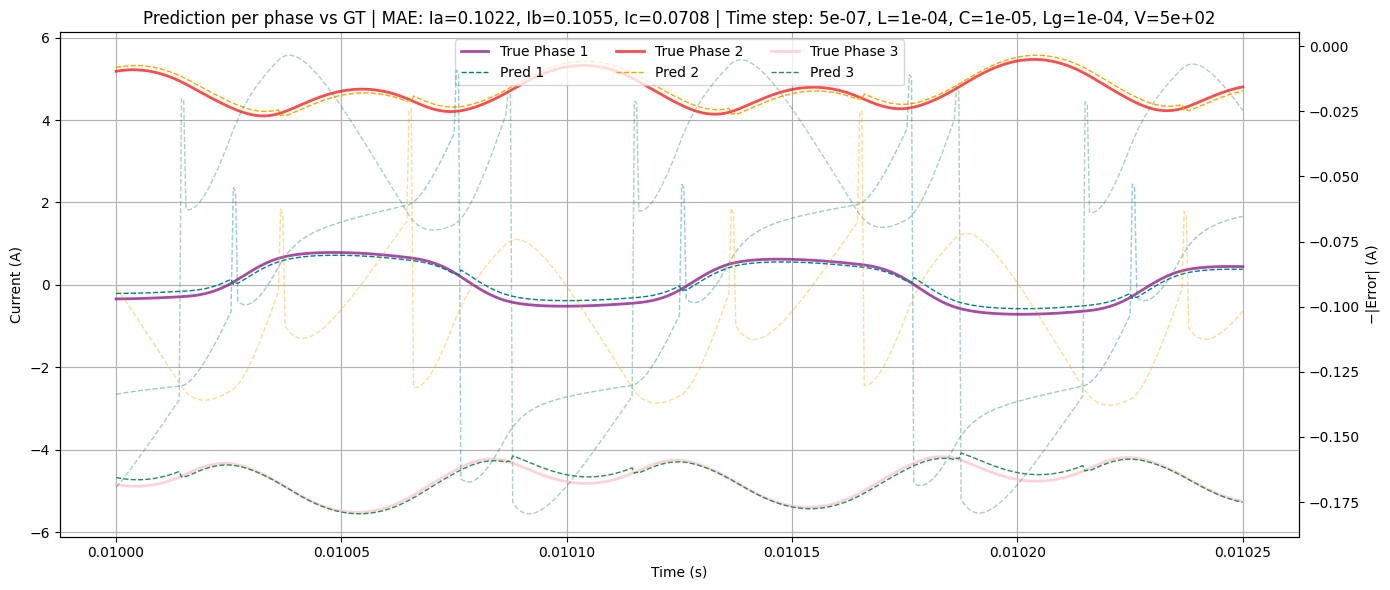

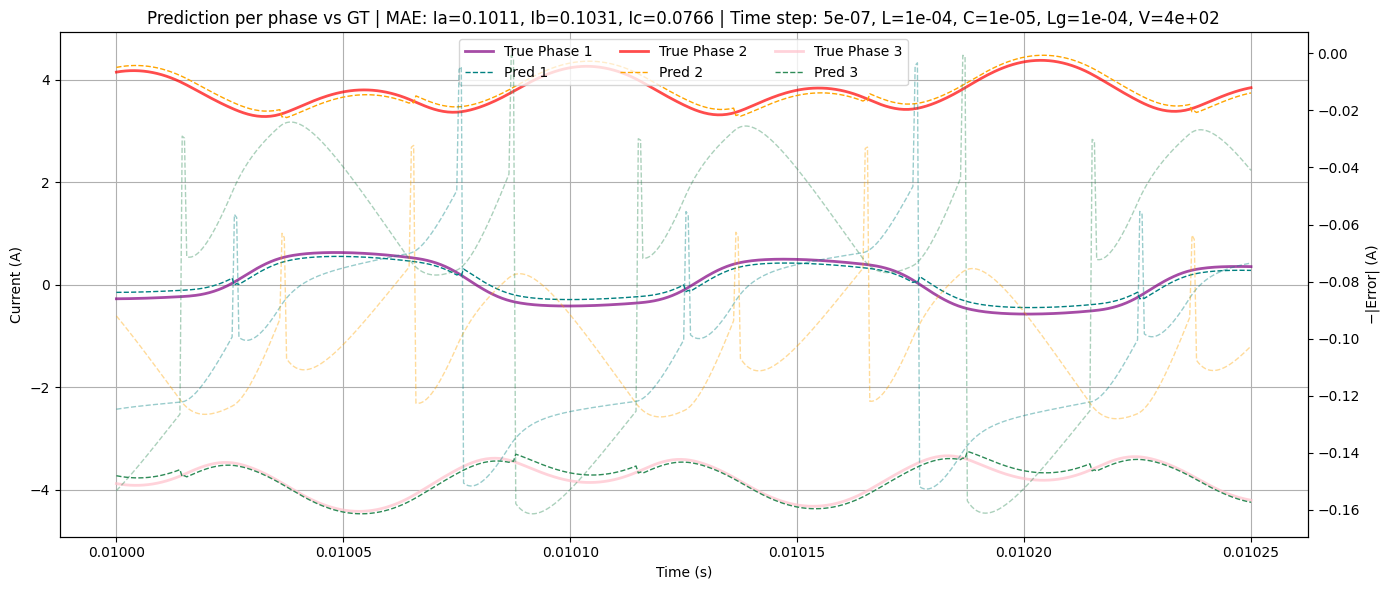

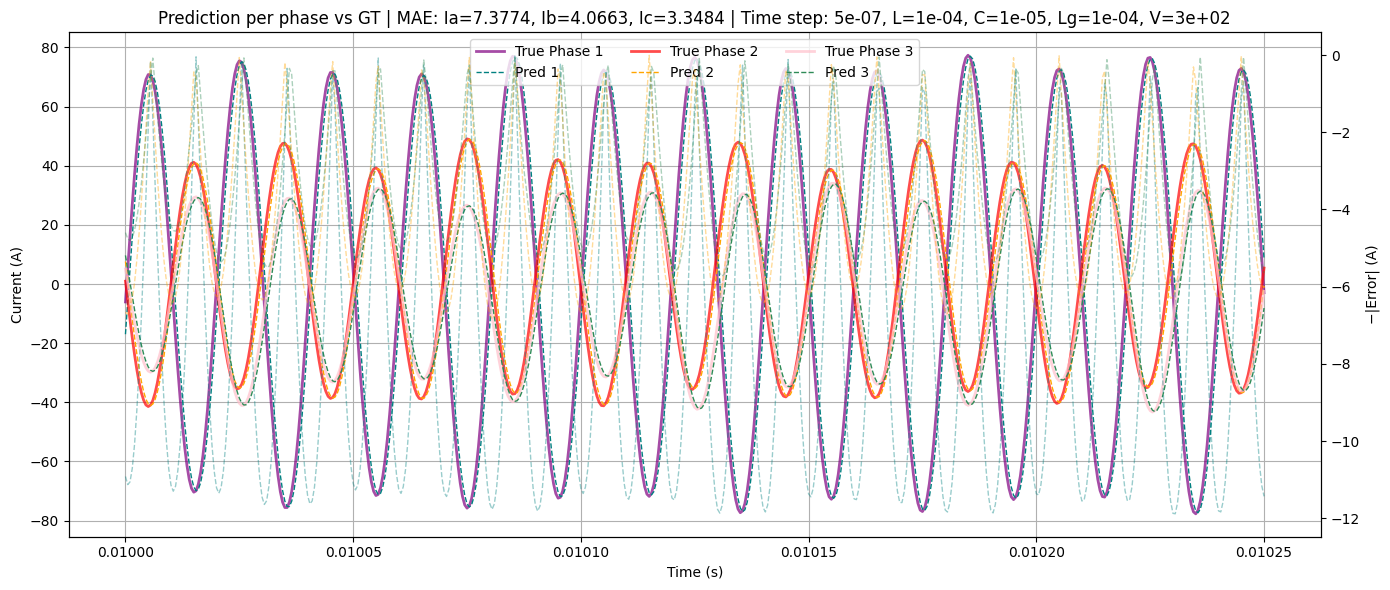

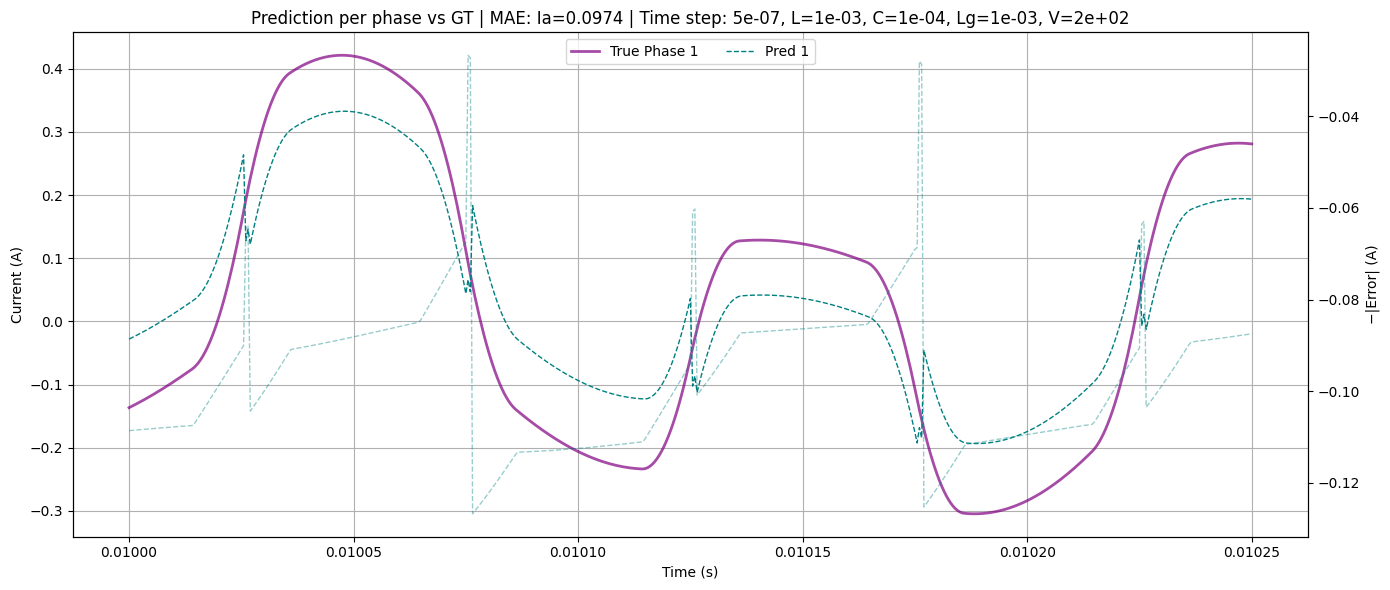

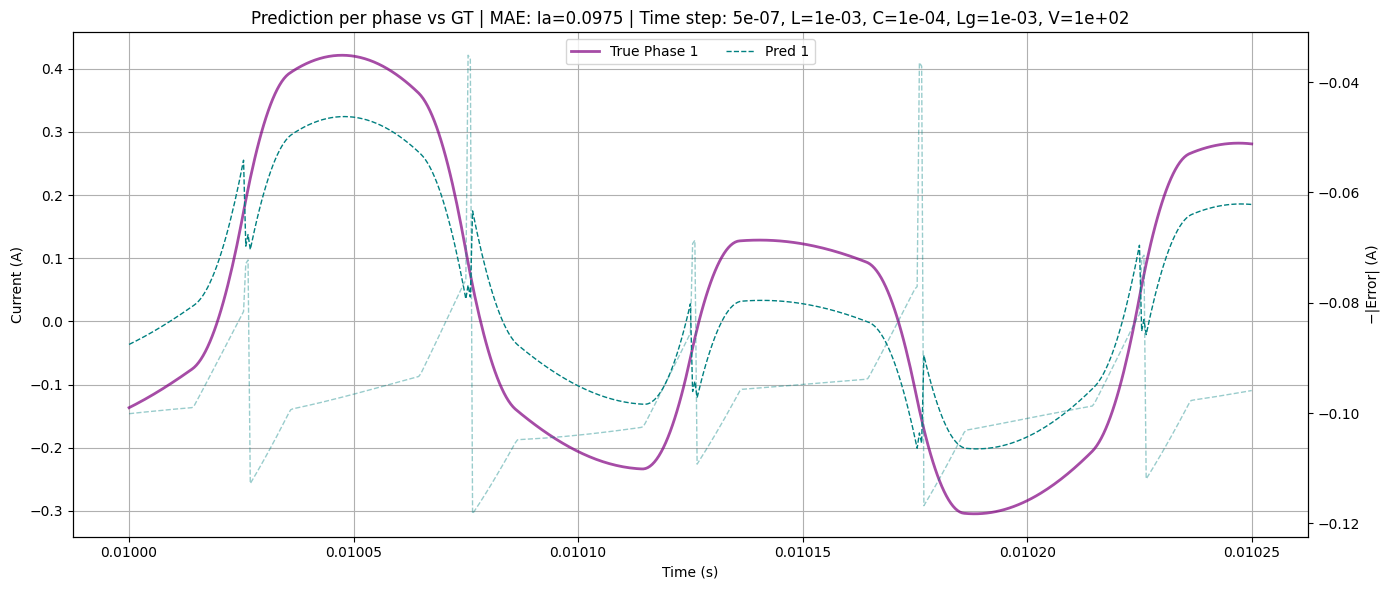

In [527]:
#name=f'1ph_inv_model_LCL_h{hidden_layers}w{neurons_per_layer}_Vin_dt=5e-07.pth'
#name="1ph_inv_model_LCL_h10w96_variable_input_small_patch.pth"
'''
hidden_layers     = 7
neurons_per_layer = 96'''

name = f'1ph_inv_model_LCL_h{hidden_layers}w{neurons_per_layer}_dt=5e-7_limited_data_no_dropout.pth'

start_time        = 0.01000
end_time          = 0.01025

csv_path="new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-07.csv"

plot_prediction_vs_truth_1model_multi_phase(model = FeedforwardNet(hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer, dropout_rate=0.2),
                                            name=name, 
                                            csv_path=csv_path, 
                                            scaler_X=dataset.scaler_X, 
                                            scaler_y=dataset.scaler_y, 
                                            hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer,
                                            start_time = start_time,
                                            end_time = end_time,
                                            phases_to_display=[0,1,2],
                                            smooth = False, 
                                            window_size = 10
                                            )

csv_path="new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-07.csv"

plot_prediction_vs_truth_1model_multi_phase(model = FeedforwardNet(hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer, dropout_rate=0),
                                            name=name, 
                                            csv_path=csv_path, 
                                            scaler_X=dataset.scaler_X, 
                                            scaler_y=dataset.scaler_y, 
                                            hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer,
                                            start_time = start_time,
                                            end_time = end_time,
                                            phases_to_display=[0,1,2],
                                            smooth = False, 
                                            window_size = 10
                                            )

csv_path="new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-07.csv"

plot_prediction_vs_truth_1model_multi_phase(model = FeedforwardNet(hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer, dropout_rate=0),
                                            name=name, 
                                            csv_path=csv_path, 
                                            scaler_X=dataset.scaler_X, 
                                            scaler_y=dataset.scaler_y, 
                                            hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer,
                                            start_time = start_time,
                                            end_time = end_time,
                                            phases_to_display=[0,1,2],
                                            smooth = False, 
                                            window_size = 10
                                            )

csv_path="new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-07.csv"

plot_prediction_vs_truth_1model_multi_phase(model = FeedforwardNet(hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer, dropout_rate=0),
                                            name=name, 
                                            csv_path=csv_path, 
                                            scaler_X=dataset.scaler_X, 
                                            scaler_y=dataset.scaler_y, 
                                            hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer,
                                            start_time = start_time,
                                            end_time = end_time,
                                            phases_to_display=[0],
                                            smooth = False, 
                                            window_size = 10
                                            )


csv_path="new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-07.csv"

plot_prediction_vs_truth_1model_multi_phase(model = FeedforwardNet(hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer, dropout_rate=0),
                                            name=name, 
                                            csv_path=csv_path, 
                                            scaler_X=dataset.scaler_X, 
                                            scaler_y=dataset.scaler_y, 
                                            hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer,
                                            start_time = start_time,
                                            end_time = end_time,
                                            phases_to_display=[0],
                                            smooth = False, 
                                            window_size = 10
                                            )

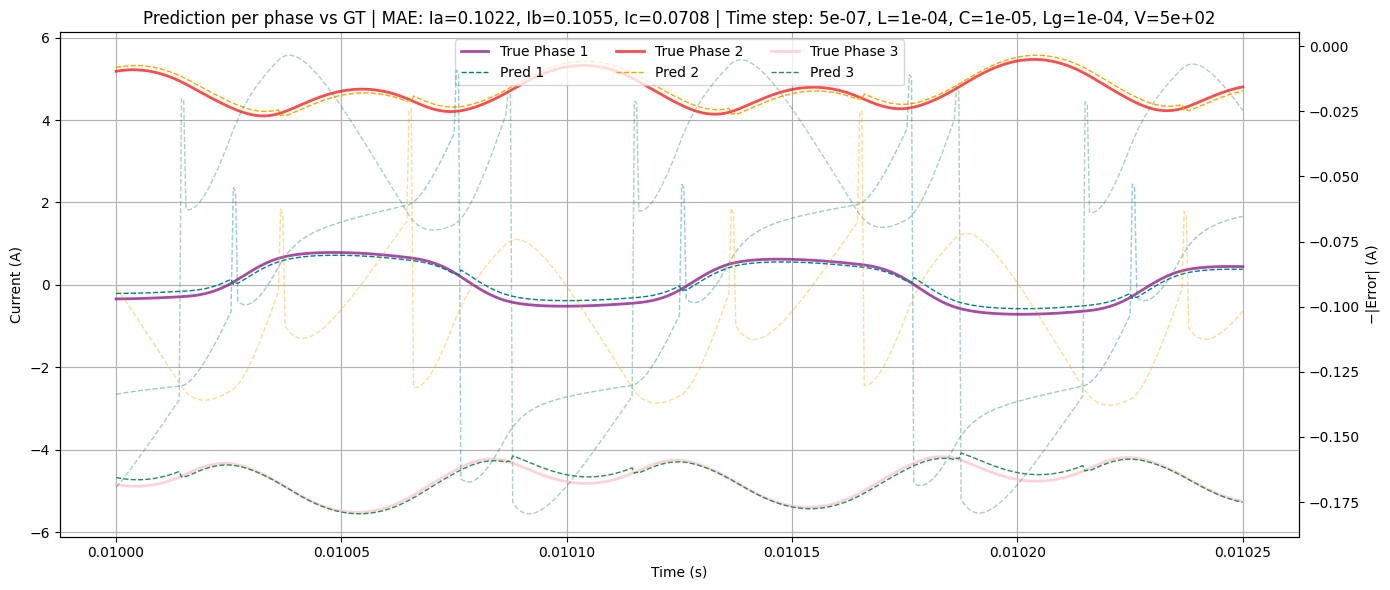

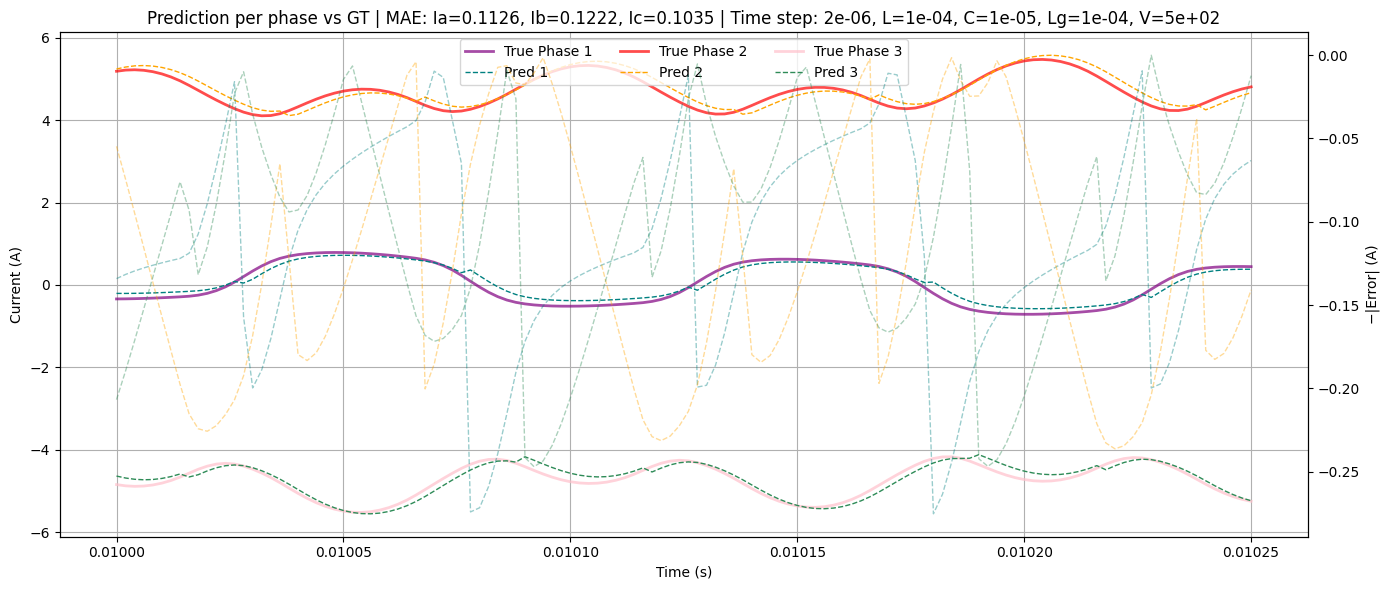

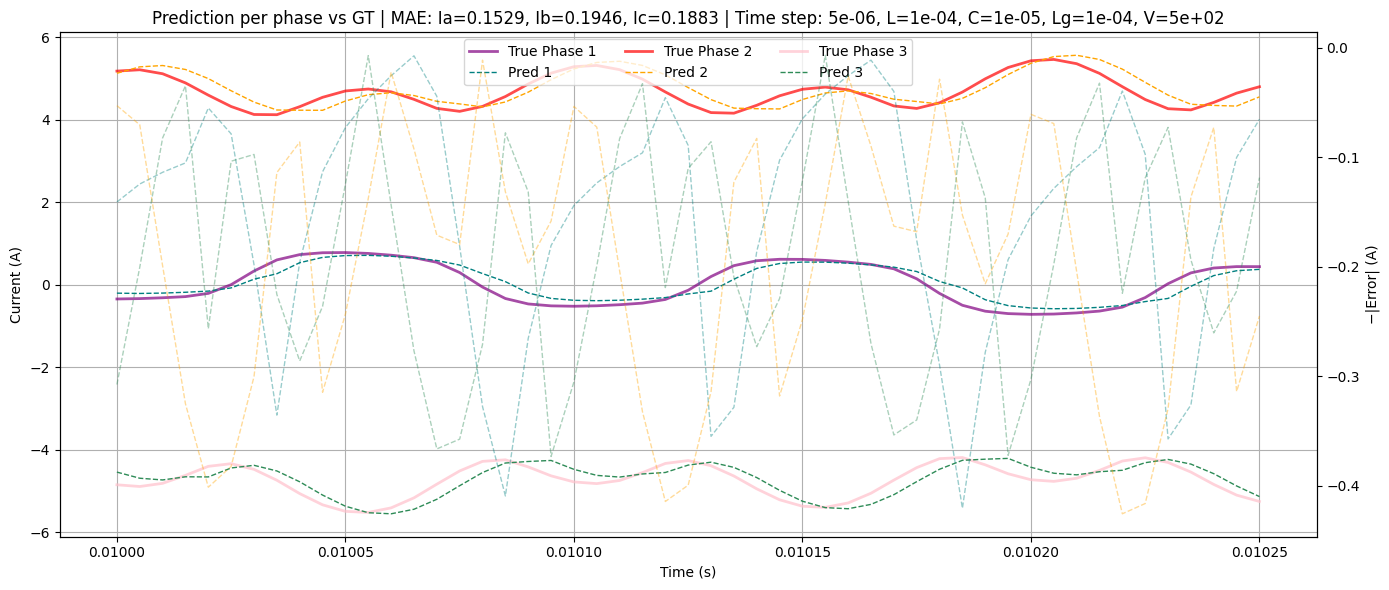

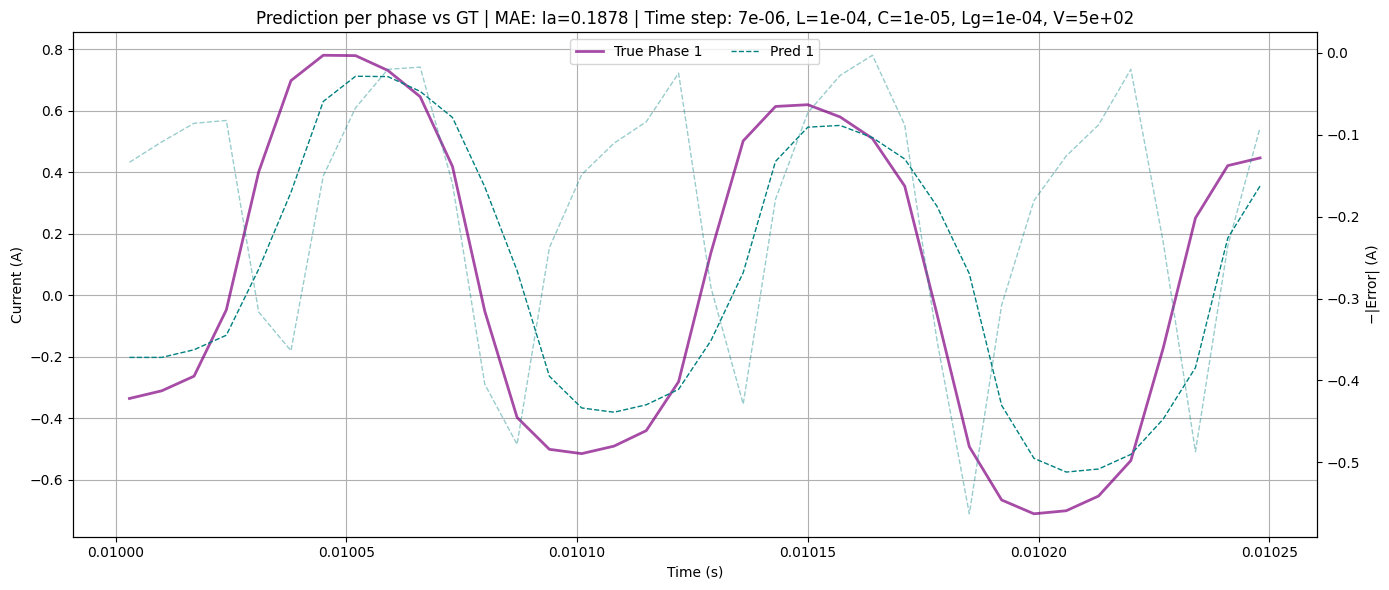

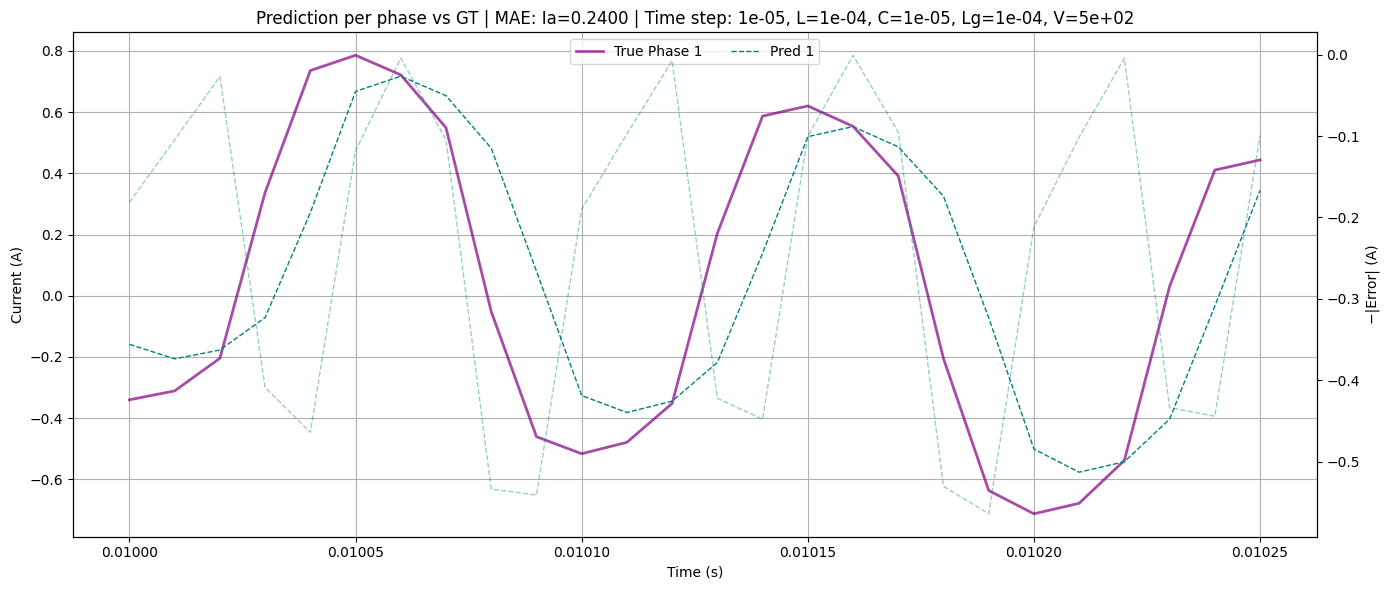

In [526]:
#name=f'1ph_inv_model_LCL_h{hidden_layers}w{neurons_per_layer}_Vin_dt=5e-07.pth'
#name="1ph_inv_model_LCL_h10w96_variable_input_small_patch.pth"

hidden_layers     = 7
neurons_per_layer = 128

name = f'1ph_inv_model_LCL_h{hidden_layers}w{neurons_per_layer}_dt=5e-7_limited_data_no_dropout.pth'

start_time        = 0.01000
end_time          = 0.01025

csv_path="new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-07.csv"

plot_prediction_vs_truth_1model_multi_phase(model = FeedforwardNet(hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer, dropout_rate=0.2),
                                            name=name, 
                                            csv_path=csv_path, 
                                            scaler_X=dataset.scaler_X, 
                                            scaler_y=dataset.scaler_y, 
                                            hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer,
                                            start_time = start_time,
                                            end_time = end_time,
                                            phases_to_display=[0,1,2],
                                            smooth = False, 
                                            window_size = 10
                                            )

csv_path="new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=5e+02_time_step_2e-06.csv"

plot_prediction_vs_truth_1model_multi_phase(model = FeedforwardNet(hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer, dropout_rate=0),
                                            name=name, 
                                            csv_path=csv_path, 
                                            scaler_X=dataset.scaler_X, 
                                            scaler_y=dataset.scaler_y, 
                                            hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer,
                                            start_time = start_time,
                                            end_time = end_time,
                                            phases_to_display=[0,1,2],
                                            smooth = False, 
                                            window_size = 10
                                            )

csv_path="new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-06.csv"

plot_prediction_vs_truth_1model_multi_phase(model = FeedforwardNet(hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer, dropout_rate=0),
                                            name=name, 
                                            csv_path=csv_path, 
                                            scaler_X=dataset.scaler_X, 
                                            scaler_y=dataset.scaler_y, 
                                            hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer,
                                            start_time = start_time,
                                            end_time = end_time,
                                            phases_to_display=[0,1,2],
                                            smooth = False, 
                                            window_size = 10
                                            )

csv_path="new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=5e+02_time_step_7e-06.csv"

plot_prediction_vs_truth_1model_multi_phase(model = FeedforwardNet(hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer, dropout_rate=0),
                                            name=name, 
                                            csv_path=csv_path, 
                                            scaler_X=dataset.scaler_X, 
                                            scaler_y=dataset.scaler_y, 
                                            hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer,
                                            start_time = start_time,
                                            end_time = end_time,
                                            phases_to_display=[0],
                                            smooth = False, 
                                            window_size = 10
                                            )


csv_path="new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=5e+02_time_step_1e-05.csv"

plot_prediction_vs_truth_1model_multi_phase(model = FeedforwardNet(hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer, dropout_rate=0),
                                            name=name, 
                                            csv_path=csv_path, 
                                            scaler_X=dataset.scaler_X, 
                                            scaler_y=dataset.scaler_y, 
                                            hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer,
                                            start_time = start_time,
                                            end_time = end_time,
                                            phases_to_display=[0],
                                            smooth = False, 
                                            window_size = 10
                                            )

In [ ]:
import torch
from itertools import product
'''
# Define lists of architectures to test
hidden_layers_list = [6, 8, 10, 12]
neurons_per_layer_list = [64, 96, 128, 256]

# Loop through all combinations
for hidden_layers, neurons_per_layer in product(hidden_layers_list, neurons_per_layer_list):
    print(f"\n🧪 Testing architecture: {hidden_layers} hidden layers, {neurons_per_layer} neurons per layer")

    # Train and validate model
    best_model_state_dict, test_set, train_losses, val_losses, model = cross_validate(
        dataset,
        input_size=input_size,
        hidden_layers=hidden_layers,
        neurons_per_layer=neurons_per_layer
    )

    # Load the best weights into the model
    model.load_state_dict(best_model_state_dict)

    # Save the model
    name = f"1ph_inv_model_h{hidden_layers}w{neurons_per_layer}_test_loop_grid_search.pth"
    torch.save(model.state_dict(), name)
    print(f"✅ Model saved as '{name}'")
'''


🧪 Testing architecture: 6 hidden layers, 64 neurons per layer

――― Fold 1 / 2 ―――


C:\Users\OgnjenPeric\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01:   0%|          | 0/305 [00:00<?, ?it/s]

Epoch 01 | T 159.637078 | V 0.370359 | LR 3.00e-04 | ‖∇‖ 824.748 | λ_phys 8.000e-03, λ_en 8.000e-03
     └── Train MSE: 159.585453, Shape: 0.051624, Phys: 0.000003, Pow: 0.000000
     └── Val   MSE: 0.365120, Shape: 0.005236, Phys: 0.000003, Pow: 0.000000


Epoch 02:   0%|          | 0/305 [00:00<?, ?it/s]

...

Epoch 11 | T 0.026343 | V 0.008428 | LR 3.00e-04 | ‖∇‖ 0.740 | λ_phys 1.789e-02, λ_en 8.000e-03
     └── Train MSE: 0.025298, Shape: 0.001039, Phys: 0.000007, Pow: 0.000000
     └── Val   MSE: 0.007741, Shape: 0.000680, Phys: 0.000007, Pow: 0.000000


Epoch 12:   0%|          | 0/305 [00:00<?, ?it/s]

Epoch 12 | T 0.021659 | V 0.007815 | LR 3.00e-04 | ‖∇‖ 0.735 | λ_phys 1.789e-02, λ_en 8.000e-03
     └── Train MSE: 0.020715, Shape: 0.000938, Phys: 0.000007, Pow: 0.000000
     └── Val   MSE: 0.007155, Shape: 0.000653, Phys: 0.000007, Pow: 0.000000


Epoch 13:   0%|          | 0/305 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [528]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from itertools import product
from collections import defaultdict
import random

def load_phase_data(df, phase):
    I   = df[f'I{phase.lower()}'].values
    top = (df[f'top{phase}'].values > 0.5).astype(float)
    bot = (df[f'bot{phase}'].values > 0.5).astype(float)
    L   = df[f'L{phase.lower()}_value'].values
    C   = df[f'C{phase.lower()}_value'].values
    Lg  = df[f'L{phase.lower()}g_value'].values
    next_I = df[f'I{phase.lower()}_next_value'].values
    time_step = df['time_step'].values
    Vin = df['Vin_value'].values
    inputs = np.stack([I, top, bot, L, C, Lg, time_step, Vin], axis=1)
    return inputs, next_I, df['time'].values

def compare_models_on_multiple_files(csv_files, input_size, output_size, model_class,
                                     hidden_layers_list, neurons_list,
                                     start_time=None, end_time=None,
                                     num_of_random_plots=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_mae_summary = defaultdict(list)
    results_per_model = defaultdict(lambda: defaultdict(list))

    for hidden_layers, neurons_per_layer in product(hidden_layers_list, neurons_list):
        model_id = f"h{hidden_layers}w{neurons_per_layer}"
        model_filename = f"1ph_inv_model_{model_id}_test_loop_grid_search.pth"
        if not os.path.exists(model_filename):
            continue

        model = model_class(input_size=input_size, hidden_layers=hidden_layers,
                            neurons_per_layer=neurons_per_layer, output_size=output_size).to(device)
        model.load_state_dict(torch.load(model_filename, map_location=device))
        model.eval()

        maes = []

        for file in csv_files:
            df = pd.read_csv(file)
            if start_time is not None and end_time is not None:
                df = df[(df['time'] >= start_time) & (df['time'] <= end_time)]

            for phase in ['A', 'B', 'C']:
                try:
                    X, y_true, time = load_phase_data(df, phase)
                    scaler_X = MinMaxScaler(feature_range=(-1, 1))
                    scaler_y = MinMaxScaler(feature_range=(-1, 1))
                    X_scaled = scaler_X.fit_transform(X)
                    y_scaled = scaler_y.fit_transform(y_true.reshape(-1, 1)).flatten()
                    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

                    with torch.no_grad():
                        y_pred_scaled = model(X_tensor).cpu().numpy().squeeze()

                    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
                    mae = mean_absolute_error(y_true, y_pred)
                    maes.append(mae)

                    results_per_model[model_id][phase].append((time, y_true, y_pred))
                except Exception as e:
                    continue

        if maes:
            model_mae_summary[model_id] = np.mean(maes)

    # Top 3 modeli
    top_models = sorted(model_mae_summary.items(), key=lambda x: x[1])[:5]

    # Nasumični odabir fajlova za prikaz
    selected_files = random.sample(csv_files, min(num_of_random_plots, len(csv_files)))
    for file in selected_files:
        df = pd.read_csv(file)
        if start_time is not None and end_time is not None:
            df = df[(df['time'] >= start_time) & (df['time'] <= end_time)]

        fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
        for i, phase in enumerate(['A', 'B', 'C']):
            axs[i].set_title(f"Phase {phase}")
            axs[i].set_ylabel("Current")

            _, y_gt, time = load_phase_data(df, phase)
            axs[i].plot(time, y_gt, label='Ground Truth', color='black', linewidth=2)

            for model_id, mae in top_models:
                try:
                    X, y_true, time = load_phase_data(df, phase)
                    scaler_X = MinMaxScaler(feature_range=(-1, 1))
                    scaler_y = MinMaxScaler(feature_range=(-1, 1))
                    X_scaled = scaler_X.fit_transform(X)
                    y_scaled = scaler_y.fit_transform(y_true.reshape(-1, 1)).flatten()
                    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

                    h, w = int(model_id[1]), int(model_id[3:])
                    model = model_class(input_size=input_size, hidden_layers=h,
                                        neurons_per_layer=w, output_size=output_size).to(device)
                    model.load_state_dict(torch.load(f"1ph_inv_model_h{h}w{w}_test_loop_grid_search.pth", map_location=device))
                    model.eval()

                    with torch.no_grad():
                        y_pred_scaled = model(X_tensor).cpu().numpy().squeeze()

                    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
                    axs[i].plot(time, y_pred, linestyle='--', label=f'{model_id} (avg MAE: {mae:.5f})')
                except Exception as e:
                    continue

            axs[i].legend()
            axs[i].grid(True)

        axs[-1].set_xlabel("Time (s)")
        fig.suptitle(os.path.basename(file))
        plt.tight_layout()
        plt.show()


In [529]:
scaler_X, scaler_y = dataset.get_scalers()
compare_models_on_multiple_files(
    csv_files=file_names,  # lista stringova ka fajlovima
    input_size=8,
    output_size=1,
    model_class=FeedforwardNet,
    hidden_layers_list=hidden_layers_list,
    neurons_list=neurons_per_layer_list,
    start_time=0.0,
    end_time=0.0009,
    num_of_random_plots=2
)


KeyboardInterrupt: 

In [530]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

def analyze_dI_dt_distribution(csv_paths, value_col="Ia", dt_col="time_step", plot=True, p1=5, p2=95):
    all_dI_dt = []

    for path in csv_paths:
        df = pd.read_csv(path)
        if value_col not in df.columns or dt_col not in df.columns:
            print(f"⚠️ Skip: '{path}' does not contain required columns.")
            continue

        I = df[value_col].values
        dt = df[dt_col].values

        # ΔI / Δt, skip first since diff shortens array by 1
        dI = np.diff(I)
        dT = dt[1:]  # align with diff(I)
        dI_dt = dI / dT
        all_dI_dt.append(dI_dt)

    # Concatenate all
    all_dI_dt = np.concatenate(all_dI_dt)

    # Stats
    d_min = np.min(all_dI_dt)
    d_max = np.max(all_dI_dt)
    p01 = np.percentile(all_dI_dt, p1)
    p99 = np.percentile(all_dI_dt, p2)
    mean = np.mean(all_dI_dt)
    std = np.std(all_dI_dt)

    print(f"min: {d_min:.2e}")
    print(f"max: {d_max:.2e}")
    print(f"{p1}%% - {p2}%% percentiles: {p01:.2e} to {p99:.2e}")
    print(f"mean ± std: {mean:.2e} ± {std:.2e}")

    # Plot
    if plot:
        plt.figure(figsize=(6, 5))
        plt.hist(all_dI_dt, bins=500, log=True)
        plt.title("Distribution of real dI/dt")
        plt.xlabel("dI/dt (A/s)")
        plt.ylabel("Frequency (log scale)")
        plt.grid(True)
        plt.show()

    return {
        "min": d_min,
        "max": d_max,
        "p01": p01,
        "p99": p99,
        "mean": mean,
        "std": std
    }


#analyze_dI_dt_distribution(csv_paths=csv_files, p1=10, p2=90)

In [531]:
def extract_data(folder):
    data = []
    for file in sorted(os.listdir(folder)):
        match = re.search(
            r"L=(?P<L>[\deE\.\-]+)_C=(?P<C>[\deE\.\-]+)_Lg=(?P<Lg>[\deE\.\-]+)_MAE=(?P<mae>[\d\.]+)",
            file
        )
        if match:
            try:
                L = float(match.group("L"))
                C = float(match.group("C"))
                Lg = float(match.group("Lg"))
                mae_str = match.group("mae").strip().strip(".")
                MAE = float(mae_str)
                data.append({"L": L, "C": C, "Lg": Lg, "MAE": MAE})
            except Exception as e:
                print(f"⚠️ Skipped {file}: {e}")
    return pd.DataFrame(data)

def draw_nested_heatmap(df, output_file="nested_heatmap_pretty.png"):
    
    import matplotlib.colors as mcolors
    df = pd.DataFrame(df)
    C_vals = sorted(df["C"].unique())
    Lg_vals = sorted(df["Lg"].unique())
    L_vals = sorted(df["L"].unique())

    fig, ax = plt.subplots(figsize=(len(C_vals)*2.5, len(Lg_vals)*2.5))

    norm = plt.Normalize(df["MAE"].min(), df["MAE"].max())
    cmap = plt.cm.viridis

    for i_c, C in enumerate(C_vals):
        for i_lg, Lg in enumerate(Lg_vals):
            sub = df[(df["C"] == C) & (df["Lg"] == Lg)]
            if sub.empty:
                continue

            base_x = i_c
            base_y = len(Lg_vals) - 1 - i_lg

            for i_l, L in enumerate(L_vals):
                val = sub[sub["L"] == L]["MAE"]
                if val.empty:
                    continue
                mae_val = val.values[0]

                row = i_l // 2
                col = i_l % 2
                x = base_x + col * 0.5
                y = base_y + row * 0.5

                color = cmap(norm(mae_val))
                ax.add_patch(plt.Rectangle((x, y), 0.5, 0.5, color=color, ec='black'))

                text_color = 'white' if mcolors.rgb_to_hsv(color[:3])[2] < 0.5 else 'black'
                ax.text(x + 0.25, y + 0.25, f"{mae_val:.3f}", ha='center', va='center', fontsize=8, color=text_color)

    ax.set_xticks([i + 0.5 for i in range(len(C_vals))])
    ax.set_xticklabels([f"{c:.0e}" for c in C_vals], fontsize=10)
    ax.set_yticks([i + 0.5 for i in range(len(Lg_vals))])
    ax.set_yticklabels([f"{lg:.0e}" for lg in reversed(Lg_vals)], fontsize=10)
    ax.set_xlabel("Capacitance C", fontsize=12)
    ax.set_ylabel("Ground Inductance Lg", fontsize=12)
    ax.set_title("MAE Heatmap per L inside each (C, Lg) Cell", fontsize=14)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
    cbar.set_label("MAE", fontsize=12)

    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    print(f"✅ Saved: {output_file}")
    plt.show()


import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import numpy as np
import pandas as pd

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import numpy as np

def draw_three_heatmaps(df, output_prefix="heatmap_metrics"):
    df = pd.DataFrame(df)

    C_vals = sorted(df["C"].unique())
    Lg_vals = sorted(df["Lg"].unique())
    L_vals = sorted(df["L"].unique())
    metrics = ["MAE", "MARE", "MAXRE"]
    titles = {
        "MAE": "Mean Absolute Error (MAE)",
        "MARE": "Mean Absolute Relative Error (MARE)",
        "MAXRE": "Max Relative Error (MAXRE)"
    }

    for metric in metrics:
        fig, ax = plt.subplots(figsize=(len(C_vals) * 1.6, len(Lg_vals) * 1.2))
        norm = plt.Normalize(df[metric].min(), df[metric].max())
        cmap = plt.cm.viridis

        for i_c, C in enumerate(C_vals):
            for i_lg, Lg in enumerate(Lg_vals):
                sub = df[(df["C"] == C) & (df["Lg"] == Lg)]
                if sub.empty:
                    continue

                base_x = i_c
                base_y = len(Lg_vals) - 1 - i_lg

                for i_l, L in enumerate(L_vals):
                    val = sub[sub["L"] == L][metric]
                    if val.empty:
                        continue
                    metric_val = val.values[0]

                    row = i_l // 2
                    col = i_l % 2
                    w, h = 0.35, 0.35
                    x = base_x + col * w
                    y = base_y + row * h

                    color = cmap(norm(metric_val))
                    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='black')
                    ax.add_patch(rect)

                    text_color = 'white' if mcolors.rgb_to_hsv(color[:3])[2] < 0.5 else 'black'
                    ax.text(x + w/2, y + h * 0.65, f"{metric_val:.3f}", ha='center', va='center', fontsize=6, color=text_color)
                    ax.text(x + w/2, y + h * 0.3, f"L={L:.0e}", ha='center', va='center', fontsize=5.5, color=text_color)

        ax.set_xticks([i + 0.35 for i in range(len(C_vals))])
        ax.set_xticklabels([f"{c:.0e}" for c in C_vals], fontsize=8)
        ax.set_yticks([i + 0.35 for i in range(len(Lg_vals))])
        ax.set_yticklabels([f"{lg:.0e}" for lg in reversed(Lg_vals)], fontsize=8)
        ax.set_xlabel("Capacitance C", fontsize=10)
        ax.set_ylabel("Ground Inductance Lg", fontsize=10)
        ax.set_title(f"{titles[metric]} per L in (C, Lg) cells", fontsize=12)

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
        cbar.set_label(metric, fontsize=10)

        plt.tight_layout()
        filename = f"{output_prefix}_{metric}.png"
        plt.savefig(filename, dpi=300)
        print(f"✅ Saved: {filename}")
        plt.close()


In [532]:
import re

def extract_params_from_filename(filename):
    pattern = r"L=(?P<L>[0-9.e+-]+)_C=(?P<C>[0-9.e+-]+)_Lg=(?P<Lg>[0-9.e+-]+)_V(?:in)?=(?P<Vin>[0-9.e+-]+).*?time_step[_=](?P<dt>[0-9.e+-]+)"
    match = re.search(pattern, filename)
    if match:
        return {
            "L": float(match["L"]),
            "C": float(match["C"]),
            "Lg": float(match["Lg"]),
            "Vin": float(match["Vin"]),
            "dt": float(match["dt"])
        }
    else:
        return {"L": None, "C": None, "Lg": None, "Vin": None, "dt": None}


In [533]:
def plot_prediction_vs_truth_1model_multi_phase(
    csv_path,
    model,
    name,
    scaler_X,
    scaler_y,
    hidden_layers,
    neurons_per_layer,
    start_time,
    end_time,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    phases_to_display=[0, 1, 2],
    smooth=True,
    window_size=200,
    save_path="prediction_vs_truth_highres.png",
):
    import numpy as np
    import torch
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error
    import re

    def rolling_mean(arr, window=250):
        return np.convolve(arr, np.ones(window)/window, mode='same')

    def safe_relative_error(true, pred):
        denom = np.where(np.abs(true) < 1e-8, 1e-8, np.abs(true))
        return np.abs(true - pred) / denom

    # === Param extraction from filename ===
    filename = os.path.splitext(csv_path)[0]
    params = extract_params_from_filename(filename)
    print(params)

    L_val, C_val, Lg_val, Vin_val, dt_val = params["L"], params["C"], params["Lg"], params["Vin"], params["dt"]
    param_text = f"L={L_val:.0e}  C={C_val:.0e}  Lg={Lg_val:.0e}  Vin={Vin_val:.0f}  dt={dt_val:.0e}"


    # === Model preparation
    model.load_state_dict(torch.load(name, map_location=device))
    model.to(device)
    model.eval()

    # === Load data
    df = pd.read_csv(csv_path)

    inputs_per_phase = {
        0: df[['Ia', 'topA', 'botA', 'time_step', "La_value", "Ca_value", "Lag_value", "Vin_value"]].values.astype(np.float32),
        1: df[['Ib', 'topB', 'botB', 'time_step', "Lb_value", "Cb_value", "Lbg_value", "Vin_value"]].values.astype(np.float32),
        2: df[['Ic', 'topC', 'botC', 'time_step', "Lc_value", "Cc_value", "Lcg_value", "Vin_value"]].values.astype(np.float32),
    }

    targets = df[['Ia_next_value', 'Ib_next_value', 'Ic_next_value']].values.astype(np.float32)
    next_time = df["time"].values + df["time_step"].values

    preds, mae_vals, mare_vals, maxre_vals = [], [], [], []
    mask = (next_time >= start_time) & (next_time <= end_time)

    for i in phases_to_display:
        X = inputs_per_phase[i]
        X_tensor = torch.tensor(scaler_X.transform(X), dtype=torch.float32).to(device)
        with torch.no_grad():
            y_pred = model(X_tensor).cpu().numpy()
        y_pred_denorm = scaler_y.inverse_transform(y_pred)
        preds.append(y_pred_denorm)

    y_pred_all = np.concatenate(preds, axis=1)
    y_true_all = targets

    # === Plotting
    plt.style.use("dark_background")
    fig, ax1 = plt.subplots(figsize=(16, 8))
    phase_colors = ["teal", "darkorange", "seagreen"]
    truth_colors = ["indigo", "firebrick", "hotpink"]
    mae_texts = []

    for idx, phase in enumerate(phases_to_display):
        true_vals = y_true_all[mask, phase]
        pred_vals = y_pred_all[mask, idx]

        mae = mean_absolute_error(true_vals, pred_vals)
        rel_errs = safe_relative_error(true_vals, pred_vals)

        mare_vals.append(np.mean(rel_errs))
        maxre_vals.append(np.max(rel_errs))
        mae_vals.append(mae)
        mae_texts.append(f"I{chr(97 + phase)}={mae:.4f}")

        if smooth:
            true_vals = rolling_mean(true_vals, window=window_size)
            pred_vals = rolling_mean(pred_vals, window=window_size)

        ax1.plot(next_time[mask], true_vals, color=truth_colors[phase], linewidth=2, label=f"True Phase {phase + 1}")
        ax1.plot(next_time[mask], pred_vals, color=phase_colors[phase], linestyle='--', linewidth=2, label=f"Pred Phase {phase + 1}")

    ax1.set_xlabel("Time (s)", fontsize=14)
    ax1.set_ylabel("Current (A)", fontsize=14)
    ax1.grid(True)

    # Error plot
    ax2 = ax1.twinx()
    for idx, phase in enumerate(phases_to_display):
        err = -np.abs(y_true_all[mask, phase] - y_pred_all[mask, idx])
        if smooth:
            err = rolling_mean(err, window=window_size)
        ax2.plot(next_time[mask], err, color=phase_colors[phase], linestyle="--", linewidth=1, alpha=1, label=f"Error {phase + 1}")
    ax2.set_ylabel("−|Error| (A)", color='gray', fontsize=14)

    avg_mae = np.mean(mae_vals)
    plt.title(f"Prediction per phase vs GT | MAE: {', '.join(mae_texts)}\n{param_text}", fontsize=16)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower center", ncol=3, fontsize=11)

    plt.tight_layout()
    filename_out = f"./pngs/madi/plot_L={L_val:.0e}_C={C_val:.0e}_Lg={Lg_val:.0e}_Vin={Vin_val:.0f}_MAE={avg_mae:.4f}.png"
    #plt.show()
    #plt.savefig(filename_out, dpi=300)
    #print(f"✅ Saved high-res figure to: {filename_out}")
    plt.close()

    return {
        "csv_path": csv_path,
        "L": L_val,
        "C": C_val,
        "Lg": Lg_val,
        "Vin": Vin_val,
        "Time step": dt_val,
        "MAE": avg_mae,
        "MARE": np.mean(mare_vals),
        "MAXRE": np.max(maxre_vals)
    }


In [534]:
#raw_data = raw_data

"""
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-03_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-05_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-02_C=1e-06_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-03_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-05_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-03_C=1e-06_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-03_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-05_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-04_C=1e-06_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-03_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-05_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-05_C=1e-06_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-03_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-05_Lg=1e-06_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-02_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-03_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-04_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-05_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-05_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-05_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-05_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-05_V=5e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-06_V=1e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-06_V=2e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-06_V=3e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-06_V=4e+02_time_step_5e-06.csv
new_3ph_inv_L=1e-06_C=1e-06_Lg=1e-06_V=5e+02_time_step_5e-06.csv
"""

import re
import pandas as pd

def filter_file_list_by_ranges(raw_data, L_range, C_range, Lg_range, Vin_range):
    pattern = re.compile(
        r"L=(?P<L>[\de\+\-\.]+)_C=(?P<C>[\de\+\-\.]+)_Lg=(?P<Lg>[\de\+\-\.]+)_V=(?P<Vin>[\de\+\-\.]+)"
    )

    entries = []
    for line in raw_data.strip().splitlines():
        line = line.strip()
        if not line:
            continue
        match = pattern.search(line)
        if match:
            L   = float(match.group("L"))
            C   = float(match.group("C"))
            Lg  = float(match.group("Lg"))
            Vin = float(match.group("Vin"))
            if (L_range[0] <= L <= L_range[1] and
                C_range[0] <= C <= C_range[1] and
                Lg_range[0] <= Lg <= Lg_range[1] and
                Vin_range[0] <= Vin <= Vin_range[1]):
                entries.append({
                    "file": line,
                    "L": L, "C": C, "Lg": Lg, "Vin": Vin
                })

    return pd.DataFrame(entries)



In [535]:
ress = []
hidden_layers=7
neurons_per_layer=128
name = f"1ph_inv_model_LCL_h7w128_dt=5e-7_limited_data_no_dropout.pth"

# Try different file name patterns - adjust this based on your actual file names
patterns = ["new*""*"]

for pattern in patterns:
    base = pattern.split("*")[0]
    csv_files = [f for f in os.listdir() if f.endswith(".csv") and f.startswith("new") 
                    and (              f.endswith("_time_step_5e-07.csv")
                                    or f.endswith("_time_step_2e-06.csv")
                                    or f.endswith("_time_step_5e-06.csv")
                                    #or f.endswith("_time_step_7e-06.csv")
                                    #or f.endswith("_time_step_1e-05.csv")
                                    )]
    if csv_files:
        print(f"Found {len(csv_files)} files with pattern '{pattern}'")
        break

if not csv_files:
    print("No CSV files found. Please check your directory.")
    # List all files in directory for debugging
    print("Files in directory:", os.listdir())
    exit(1)


for f in csv_files:
    ress.append(
            plot_prediction_vs_truth_1model_multi_phase(
                csv_path=f,
                model=FeedforwardNet(hidden_layers=hidden_layers, neurons_per_layer=neurons_per_layer, input_size=input_size, output_size=output_size),
                name=name,
                scaler_X=dataset.scaler_X,
                scaler_y=dataset.scaler_y,
                hidden_layers=hidden_layers,
                neurons_per_layer=neurons_per_layer,
                start_time=0.01,
                end_time=0.03,
                smooth=False,
                window_size=300,
                phases_to_display=[0, 1, 2]
            )
    )

Found 1500 files with pattern 'new**'
{'L': 0.01, 'C': 0.001, 'Lg': 0.01, 'Vin': 100.0, 'dt': 2e-06}
{'L': 0.01, 'C': 0.001, 'Lg': 0.01, 'Vin': 100.0, 'dt': 5e-06}
{'L': 0.01, 'C': 0.001, 'Lg': 0.01, 'Vin': 100.0, 'dt': 5e-07}
{'L': 0.01, 'C': 0.001, 'Lg': 0.01, 'Vin': 200.0, 'dt': 2e-06}
{'L': 0.01, 'C': 0.001, 'Lg': 0.01, 'Vin': 200.0, 'dt': 5e-06}
{'L': 0.01, 'C': 0.001, 'Lg': 0.01, 'Vin': 200.0, 'dt': 5e-07}
{'L': 0.01, 'C': 0.001, 'Lg': 0.01, 'Vin': 300.0, 'dt': 2e-06}
{'L': 0.01, 'C': 0.001, 'Lg': 0.01, 'Vin': 300.0, 'dt': 5e-06}
{'L': 0.01, 'C': 0.001, 'Lg': 0.01, 'Vin': 300.0, 'dt': 5e-07}
{'L': 0.01, 'C': 0.001, 'Lg': 0.01, 'Vin': 400.0, 'dt': 2e-06}
{'L': 0.01, 'C': 0.001, 'Lg': 0.01, 'Vin': 400.0, 'dt': 5e-06}
{'L': 0.01, 'C': 0.001, 'Lg': 0.01, 'Vin': 400.0, 'dt': 5e-07}
{'L': 0.01, 'C': 0.001, 'Lg': 0.01, 'Vin': 500.0, 'dt': 2e-06}
{'L': 0.01, 'C': 0.001, 'Lg': 0.01, 'Vin': 500.0, 'dt': 5e-06}
{'L': 0.01, 'C': 0.001, 'Lg': 0.01, 'Vin': 500.0, 'dt': 5e-07}
{'L': 0.01, 'C': 

In [536]:
df_filtered = filter_file_list_by_ranges(
    raw_data,
    L_range=(1e-2, 10e-3),
    C_range=(1e-2, 100e-4),
    Lg_range=(1e-2, 10e-3),
    Vin_range=(100, 500)
)

print(df_filtered.head())

# Pretvori listu rečnika u DataFrame
results_df = pd.DataFrame(ress)

# Sačuvaj u CSV
results_df.to_csv("evaluation_results_fixed.csv", index=False)



print(results_df["Time step"])
print("✅ Saved corrected results to evaluation_results_fixed.csv")


Empty DataFrame
Columns: []
Index: []
0       2.000000e-06
1       5.000000e-06
2       5.000000e-07
3       2.000000e-06
4       5.000000e-06
            ...     
1495    5.000000e-06
1496    5.000000e-07
1497    2.000000e-06
1498    5.000000e-06
1499    5.000000e-07
Name: Time step, Length: 1500, dtype: float64
✅ Saved corrected results to evaluation_results_fixed.csv


               MAE         MARE         MAXRE
count  1500.000000  1500.000000  1.500000e+03
mean      1.087684     1.605138  2.256832e+04
std       4.661485     9.214804  1.299175e+05
min       0.081690     0.048906  3.599961e+01
25%       0.092236     0.182969  5.386998e+02
50%       0.095374     0.314254  1.884240e+03
75%       0.151026     0.748651  5.545442e+03
max      74.438998   162.854430  1.928064e+06


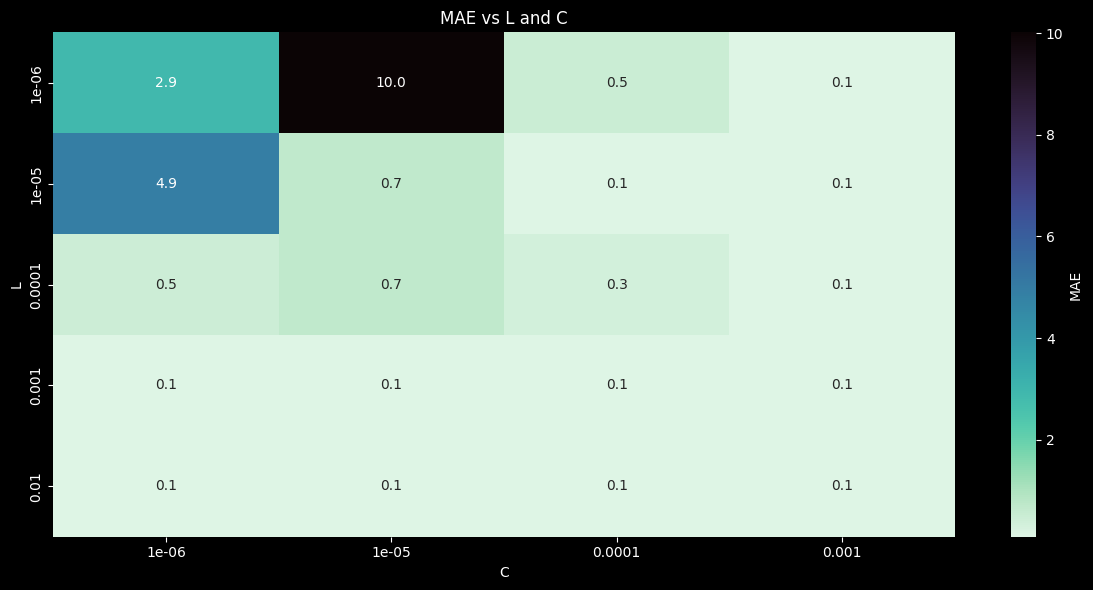

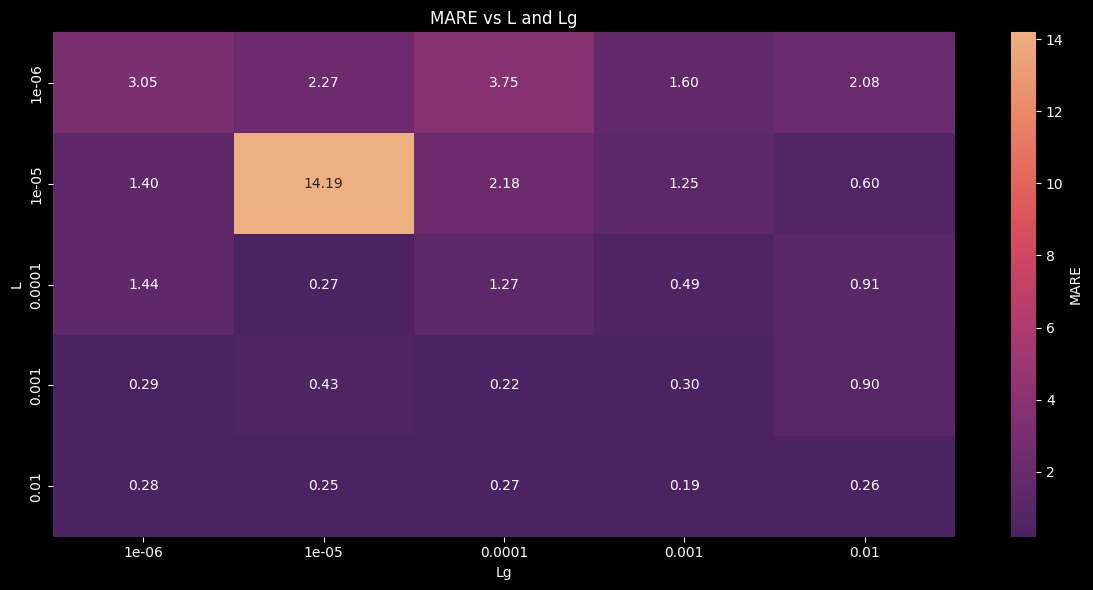

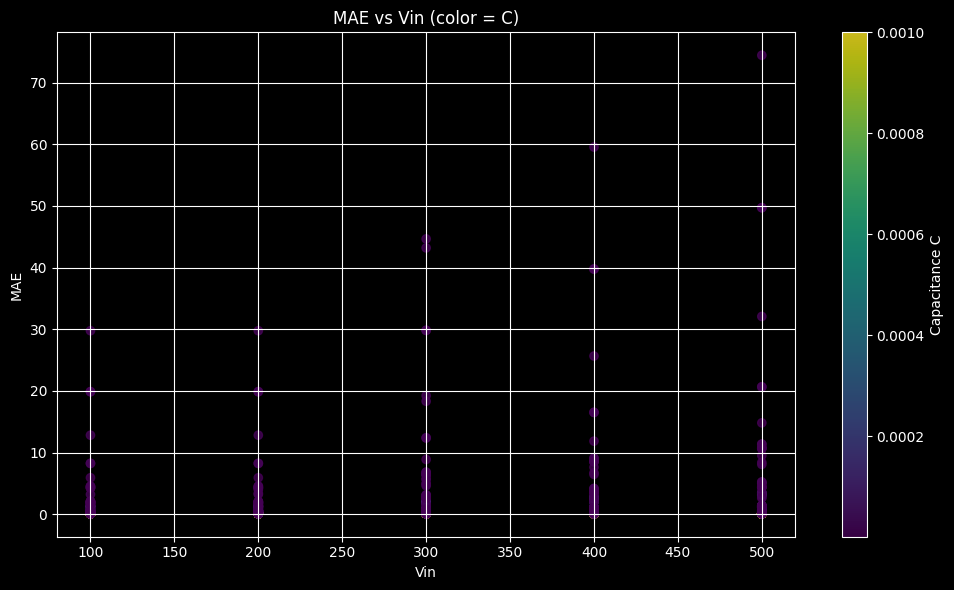

In [537]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Učitavanje rezultata
df = pd.read_csv("evaluation_results_fixed.csv")

# Uklanjanje NaN i infinities
df = df.replace([float('inf'), -float('inf')], pd.NA).dropna()

# Deskriptivna statistika grešaka
print(df[["MAE", "MARE", "MAXRE"]].describe())

# MAE vs L i C
plt.figure(figsize=(12, 6))
pivot_mae = df.pivot_table(index="L", columns="C", values="MAE", aggfunc="mean")
sns.heatmap(pivot_mae, annot=True, fmt=".1f", cmap="mako_r", cbar_kws={"label": "MAE"})
plt.title("MAE vs L and C")
plt.tight_layout()
plt.show()

# MARE vs L i Lg
plt.figure(figsize=(12, 6))
pivot_mare = df.pivot_table(index="L", columns="Lg", values="MARE", aggfunc="mean")
sns.heatmap(pivot_mare, annot=True, fmt=".2f", cmap="flare_r", cbar_kws={"label": "MARE"})
plt.title("MARE vs L and Lg")
plt.tight_layout()
plt.show()

# Scatter plot: MAE vs Vin (kolorisan po C)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df["Vin"], df["MAE"], c=df["C"], cmap="viridis", alpha=0.8)
plt.colorbar(scatter, label="Capacitance C")
plt.xlabel("Vin")
plt.ylabel("MAE")
plt.title("MAE vs Vin (color = C)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [538]:
def draw_merged_heatmaps_by_Vin(
    df,
    metrics=["MAE", "MARE", "MAXRE"],
    time_step_filter=None,  # ← dodat filter,
    output_file="heatmaps_by_Vin.png",
):
    df = pd.DataFrame(df)

    if time_step_filter is not None:
        df = df[np.isclose(df["Time step"], time_step_filter)]
        if df.empty:
            raise ValueError(f"Nema podataka za Time step = {time_step_filter}")

    # Grupacija nije potrebna jer je time step već fiksiran
    L_vals = sorted(df["L"].unique())
    Vin_vals = sorted(df["Vin"].unique())
    print(Vin_vals)
    fig, axes = plt.subplots(len(metrics) * len(Vin_vals), len(L_vals),
                             figsize=(4 * len(L_vals), 3.5 * len(metrics) * len(Vin_vals)))
    axes = np.array(axes).reshape(len(metrics) * len(Vin_vals), len(L_vals))

    cmap = "viridis"

    for metric_idx, metric in enumerate(metrics):
        vmin = df[metric].min()
        vmax = df[metric].max()

        for vin_idx, vin_val in enumerate(Vin_vals):
            vin_group = df[df["Vin"] == vin_val]

            for l_idx, L_val in enumerate(L_vals):
                ax = axes[vin_idx * len(metrics) + metric_idx][l_idx]
                subset = vin_group[vin_group["L"] == L_val]
                pivot = subset.pivot(index="Lg", columns="C", values=metric)

                sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap,
                            cbar=(l_idx == len(L_vals) - 1), ax=ax,
                            vmin=vmin, vmax=vmax, annot_kws={"size": 6})

                if metric_idx == 0:
                    ax.set_title(f"L={L_val:.0e}", fontsize=10)
                if l_idx == 0:
                    ax.set_ylabel(f"Vin={vin_val:.0f}\n{metric}", fontsize=9)
                else:
                    ax.set_ylabel("")
                ax.set_xlabel("")

    for ax in axes.flat:
        ax.set_xlabel("C", fontsize=8)
        ax.set_ylabel("Lg", fontsize=8)
        ax.tick_params(axis='both', labelsize=7)

    plt.tight_layout()
    output_file = f"heatmaps_by_Vin_dt={time_step_filter}"
    plt.savefig(output_file, dpi=300)
    print(f"✅ Saved: {output_file}")
    plt.show()


[np.float64(100.0), np.float64(200.0), np.float64(300.0), np.float64(400.0), np.float64(500.0)]
✅ Saved: heatmaps_by_Vin_dt=5e-07


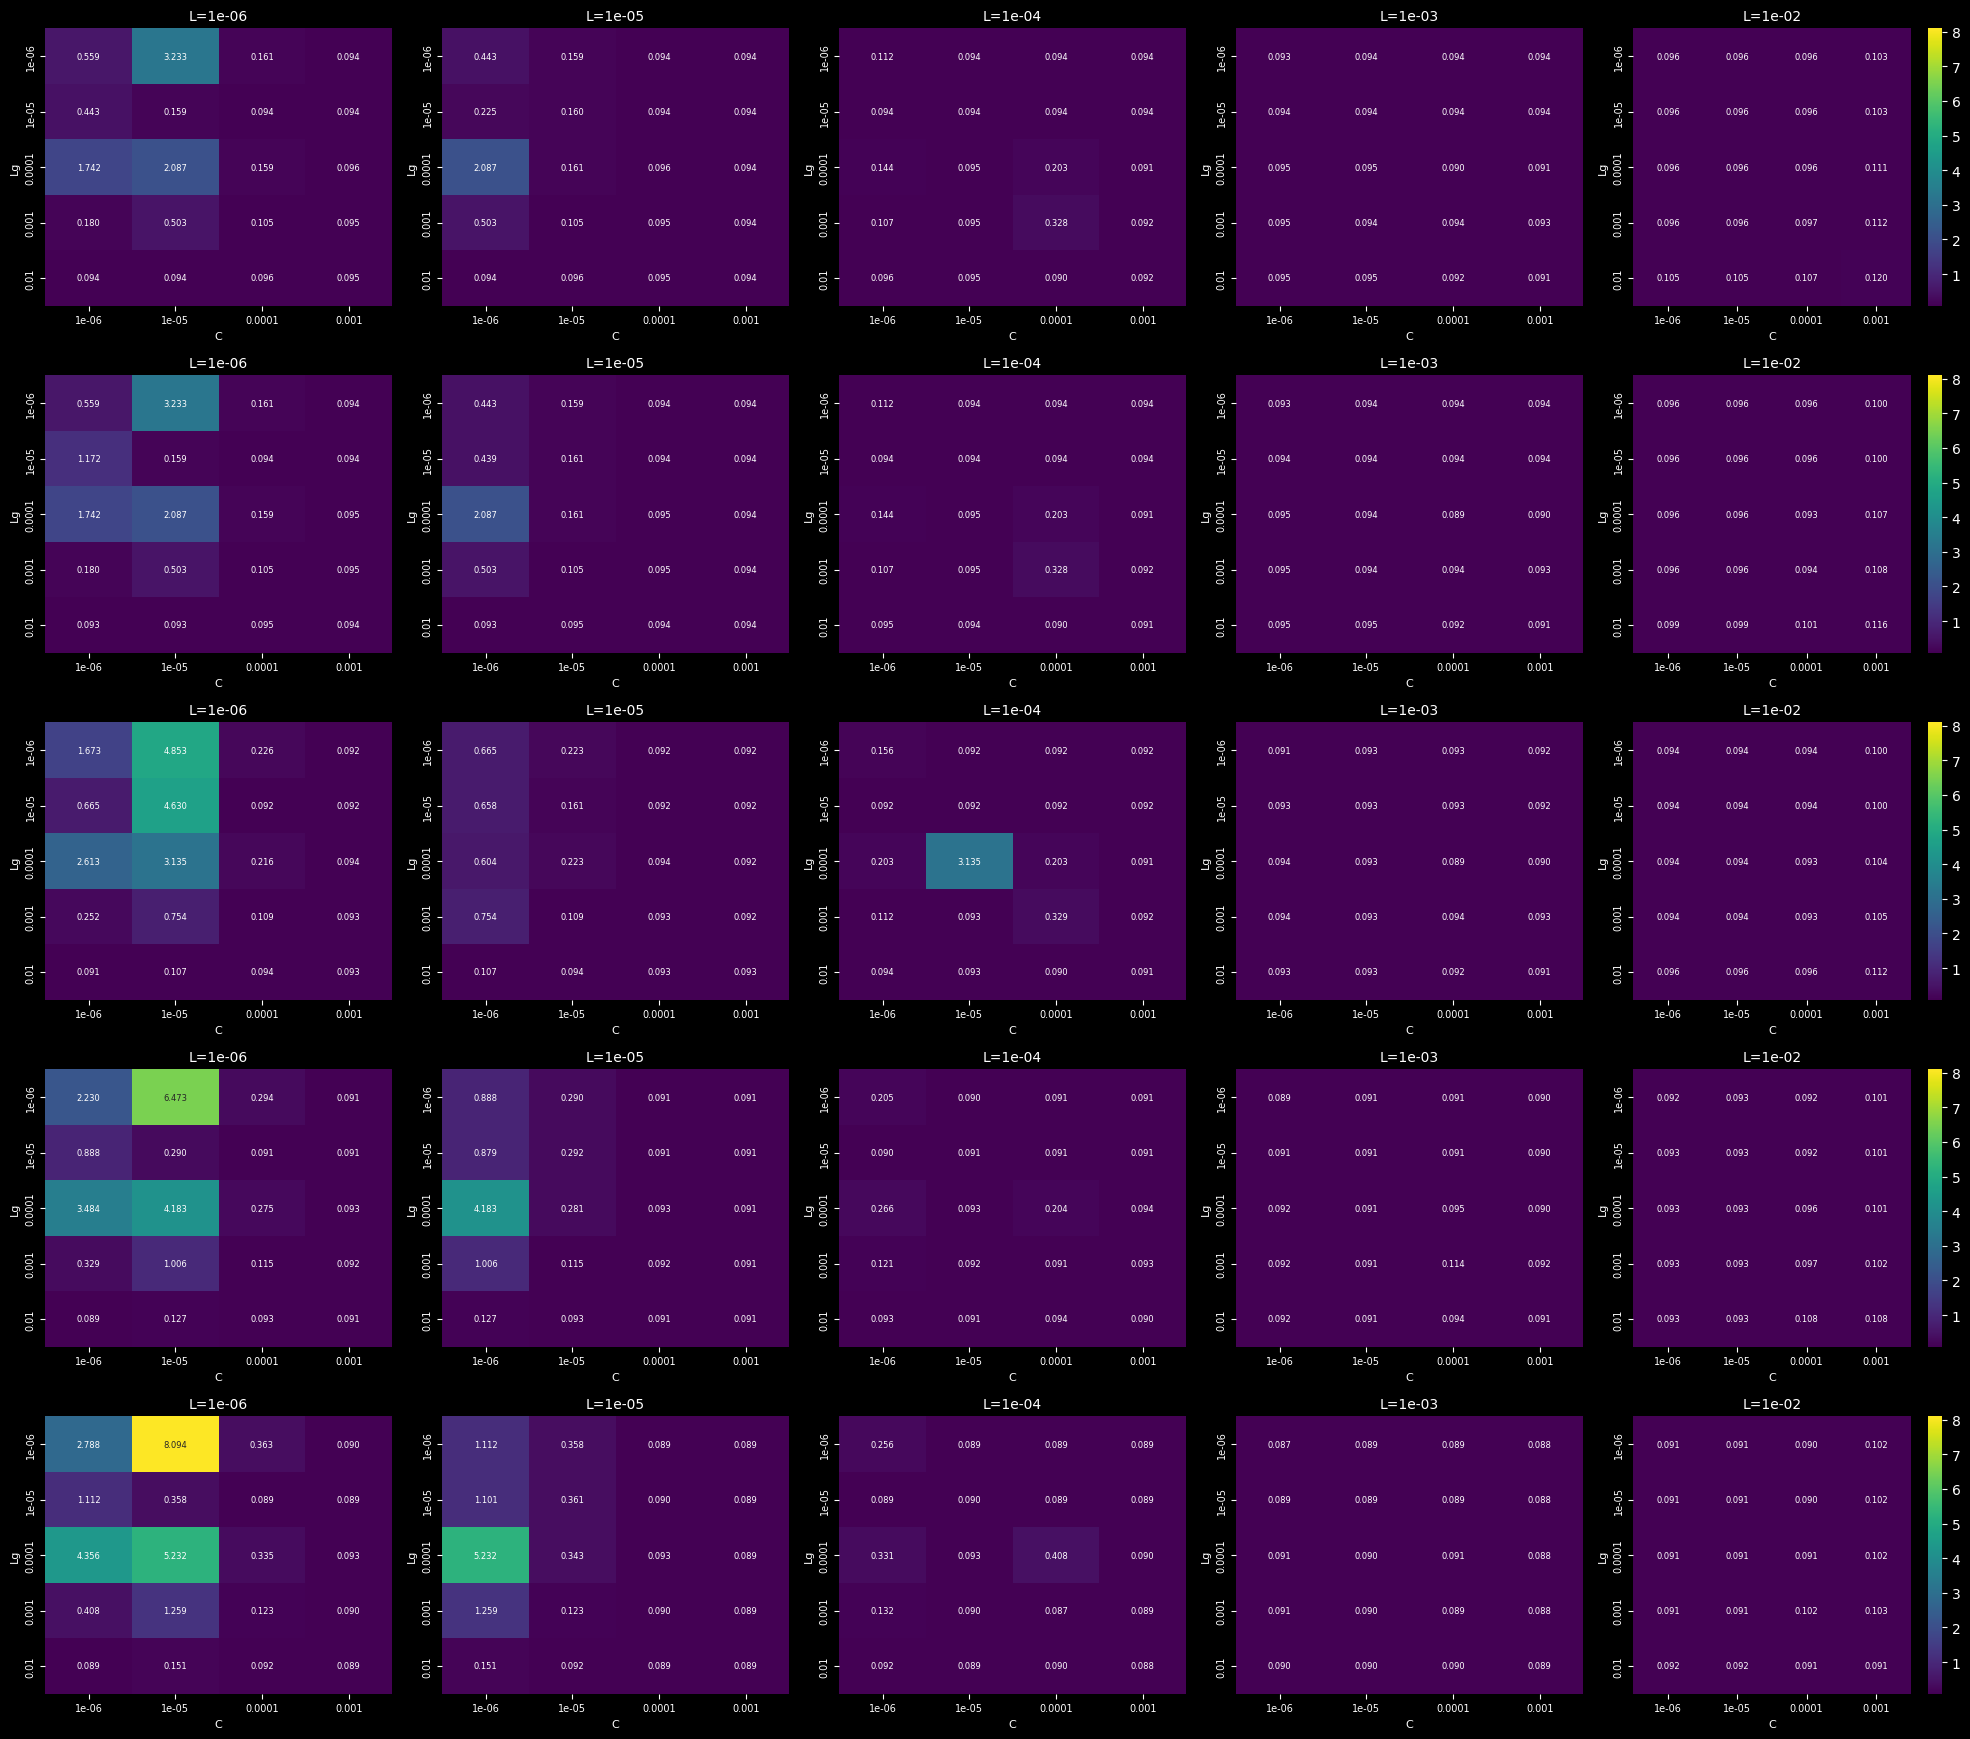

[np.float64(100.0), np.float64(200.0), np.float64(300.0), np.float64(400.0), np.float64(500.0)]
✅ Saved: heatmaps_by_Vin_dt=2e-06


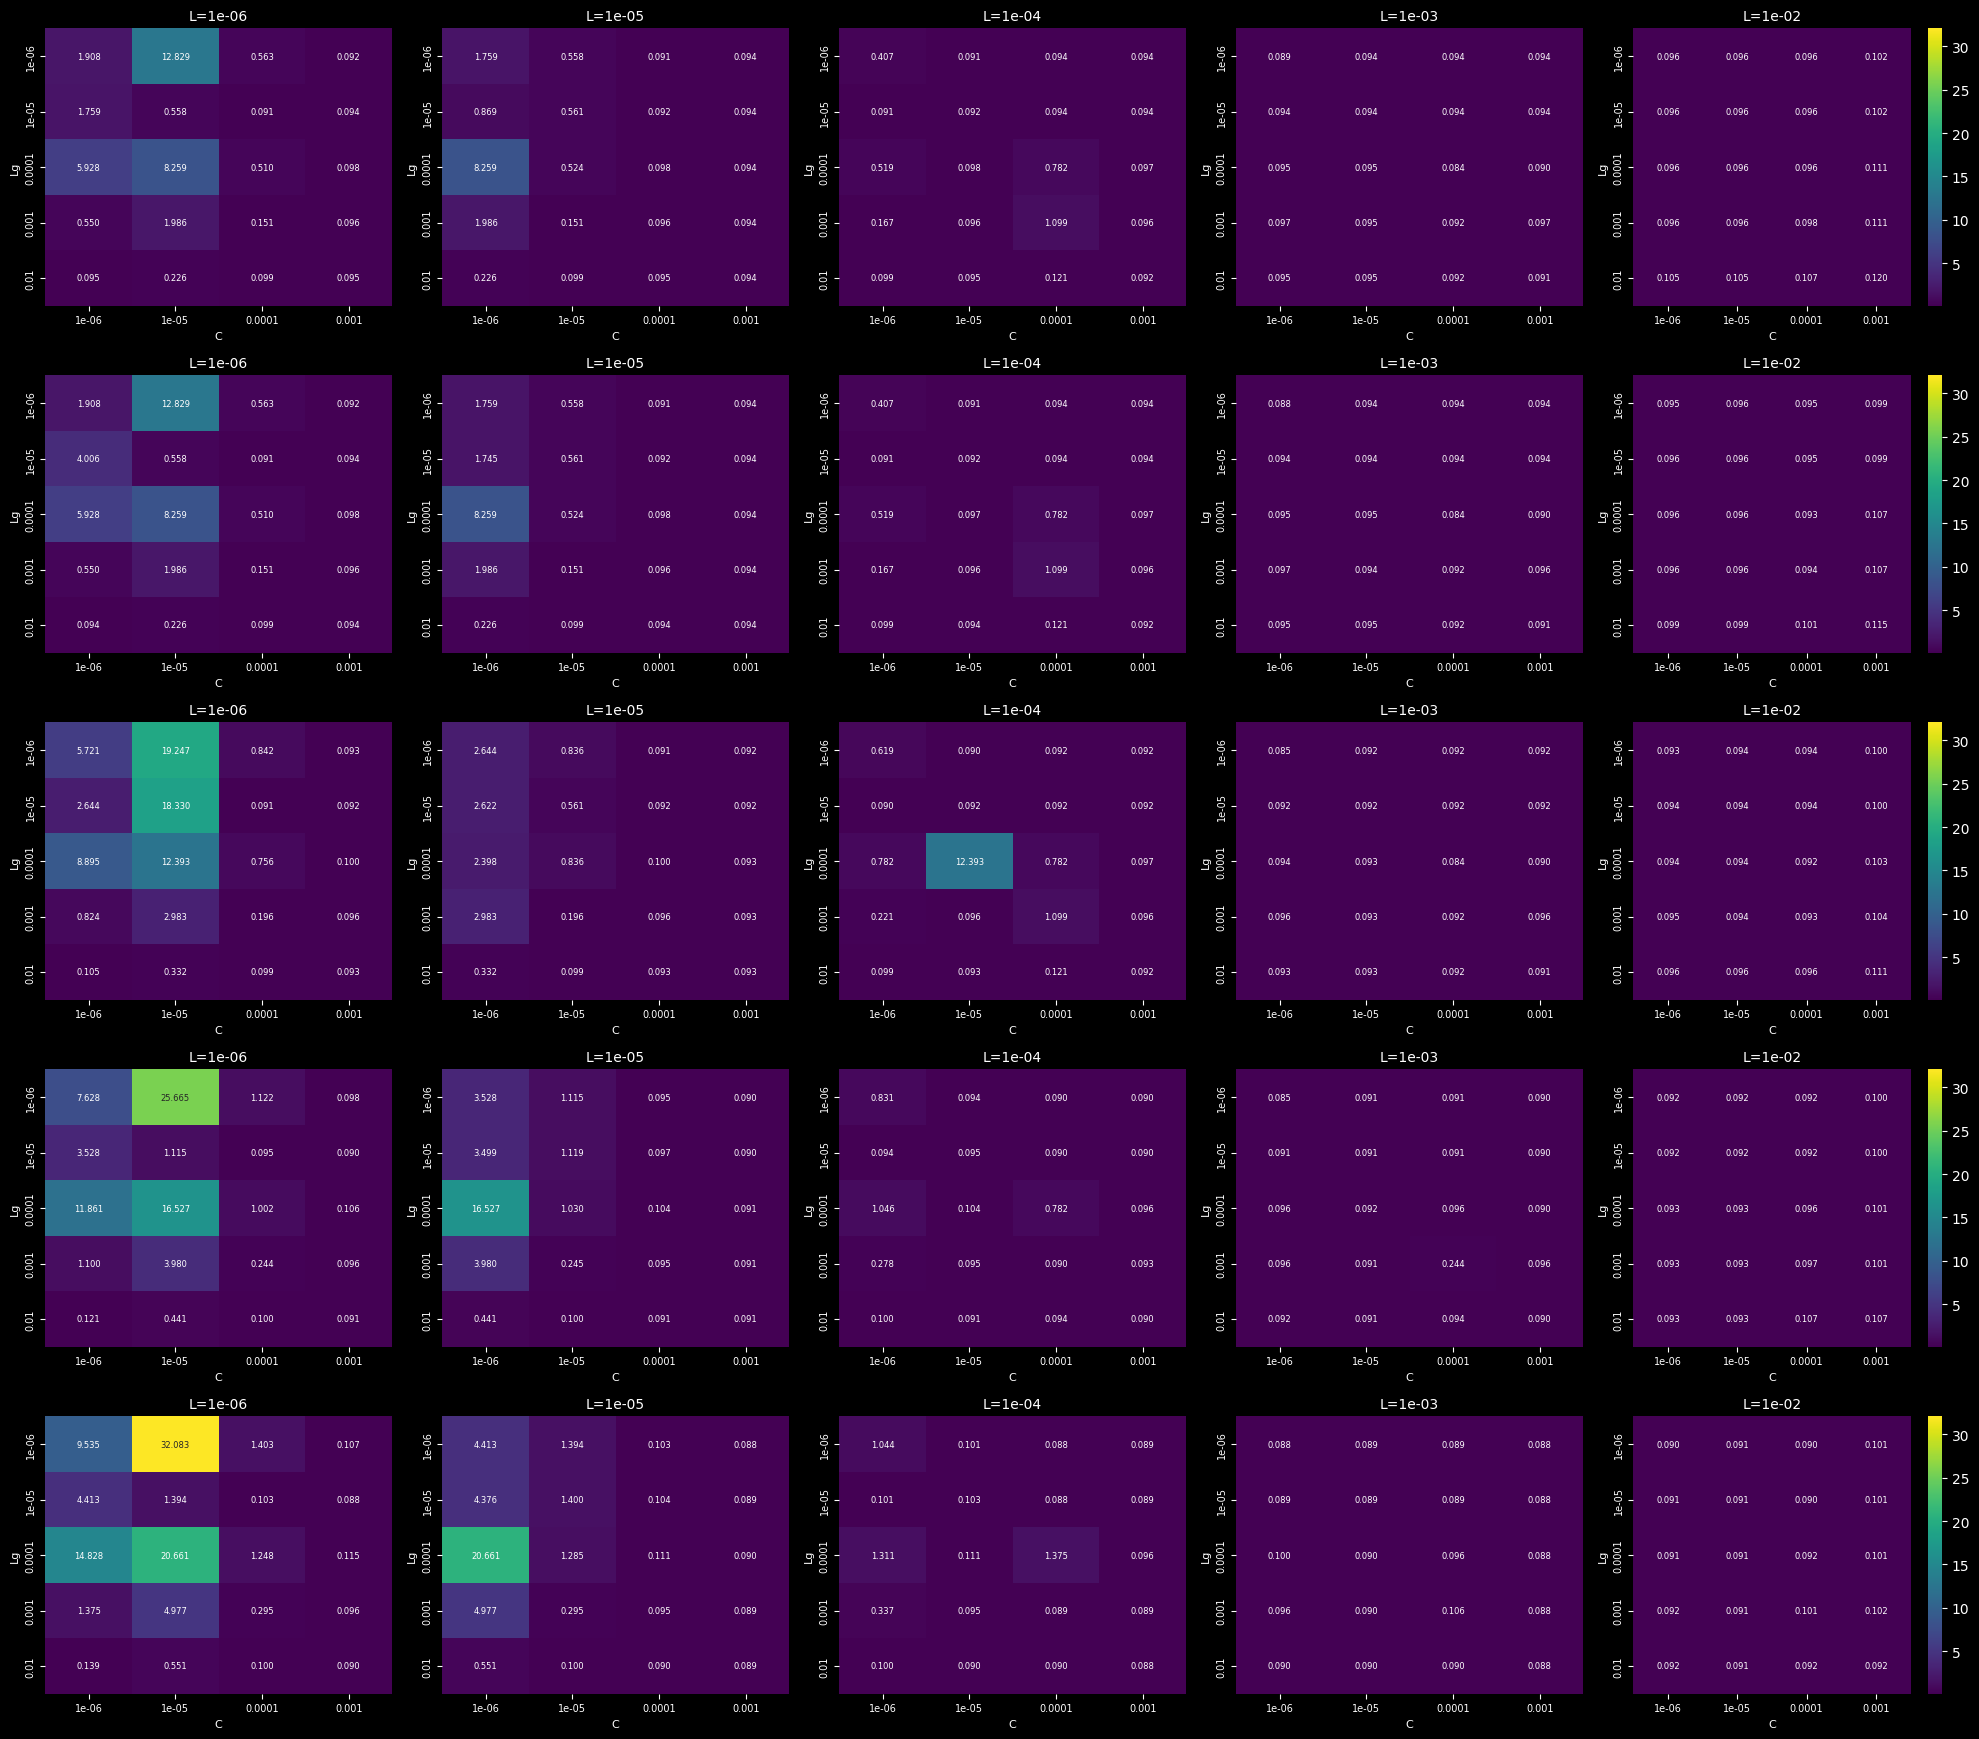

[np.float64(100.0), np.float64(200.0), np.float64(300.0), np.float64(400.0), np.float64(500.0)]
✅ Saved: heatmaps_by_Vin_dt=5e-06


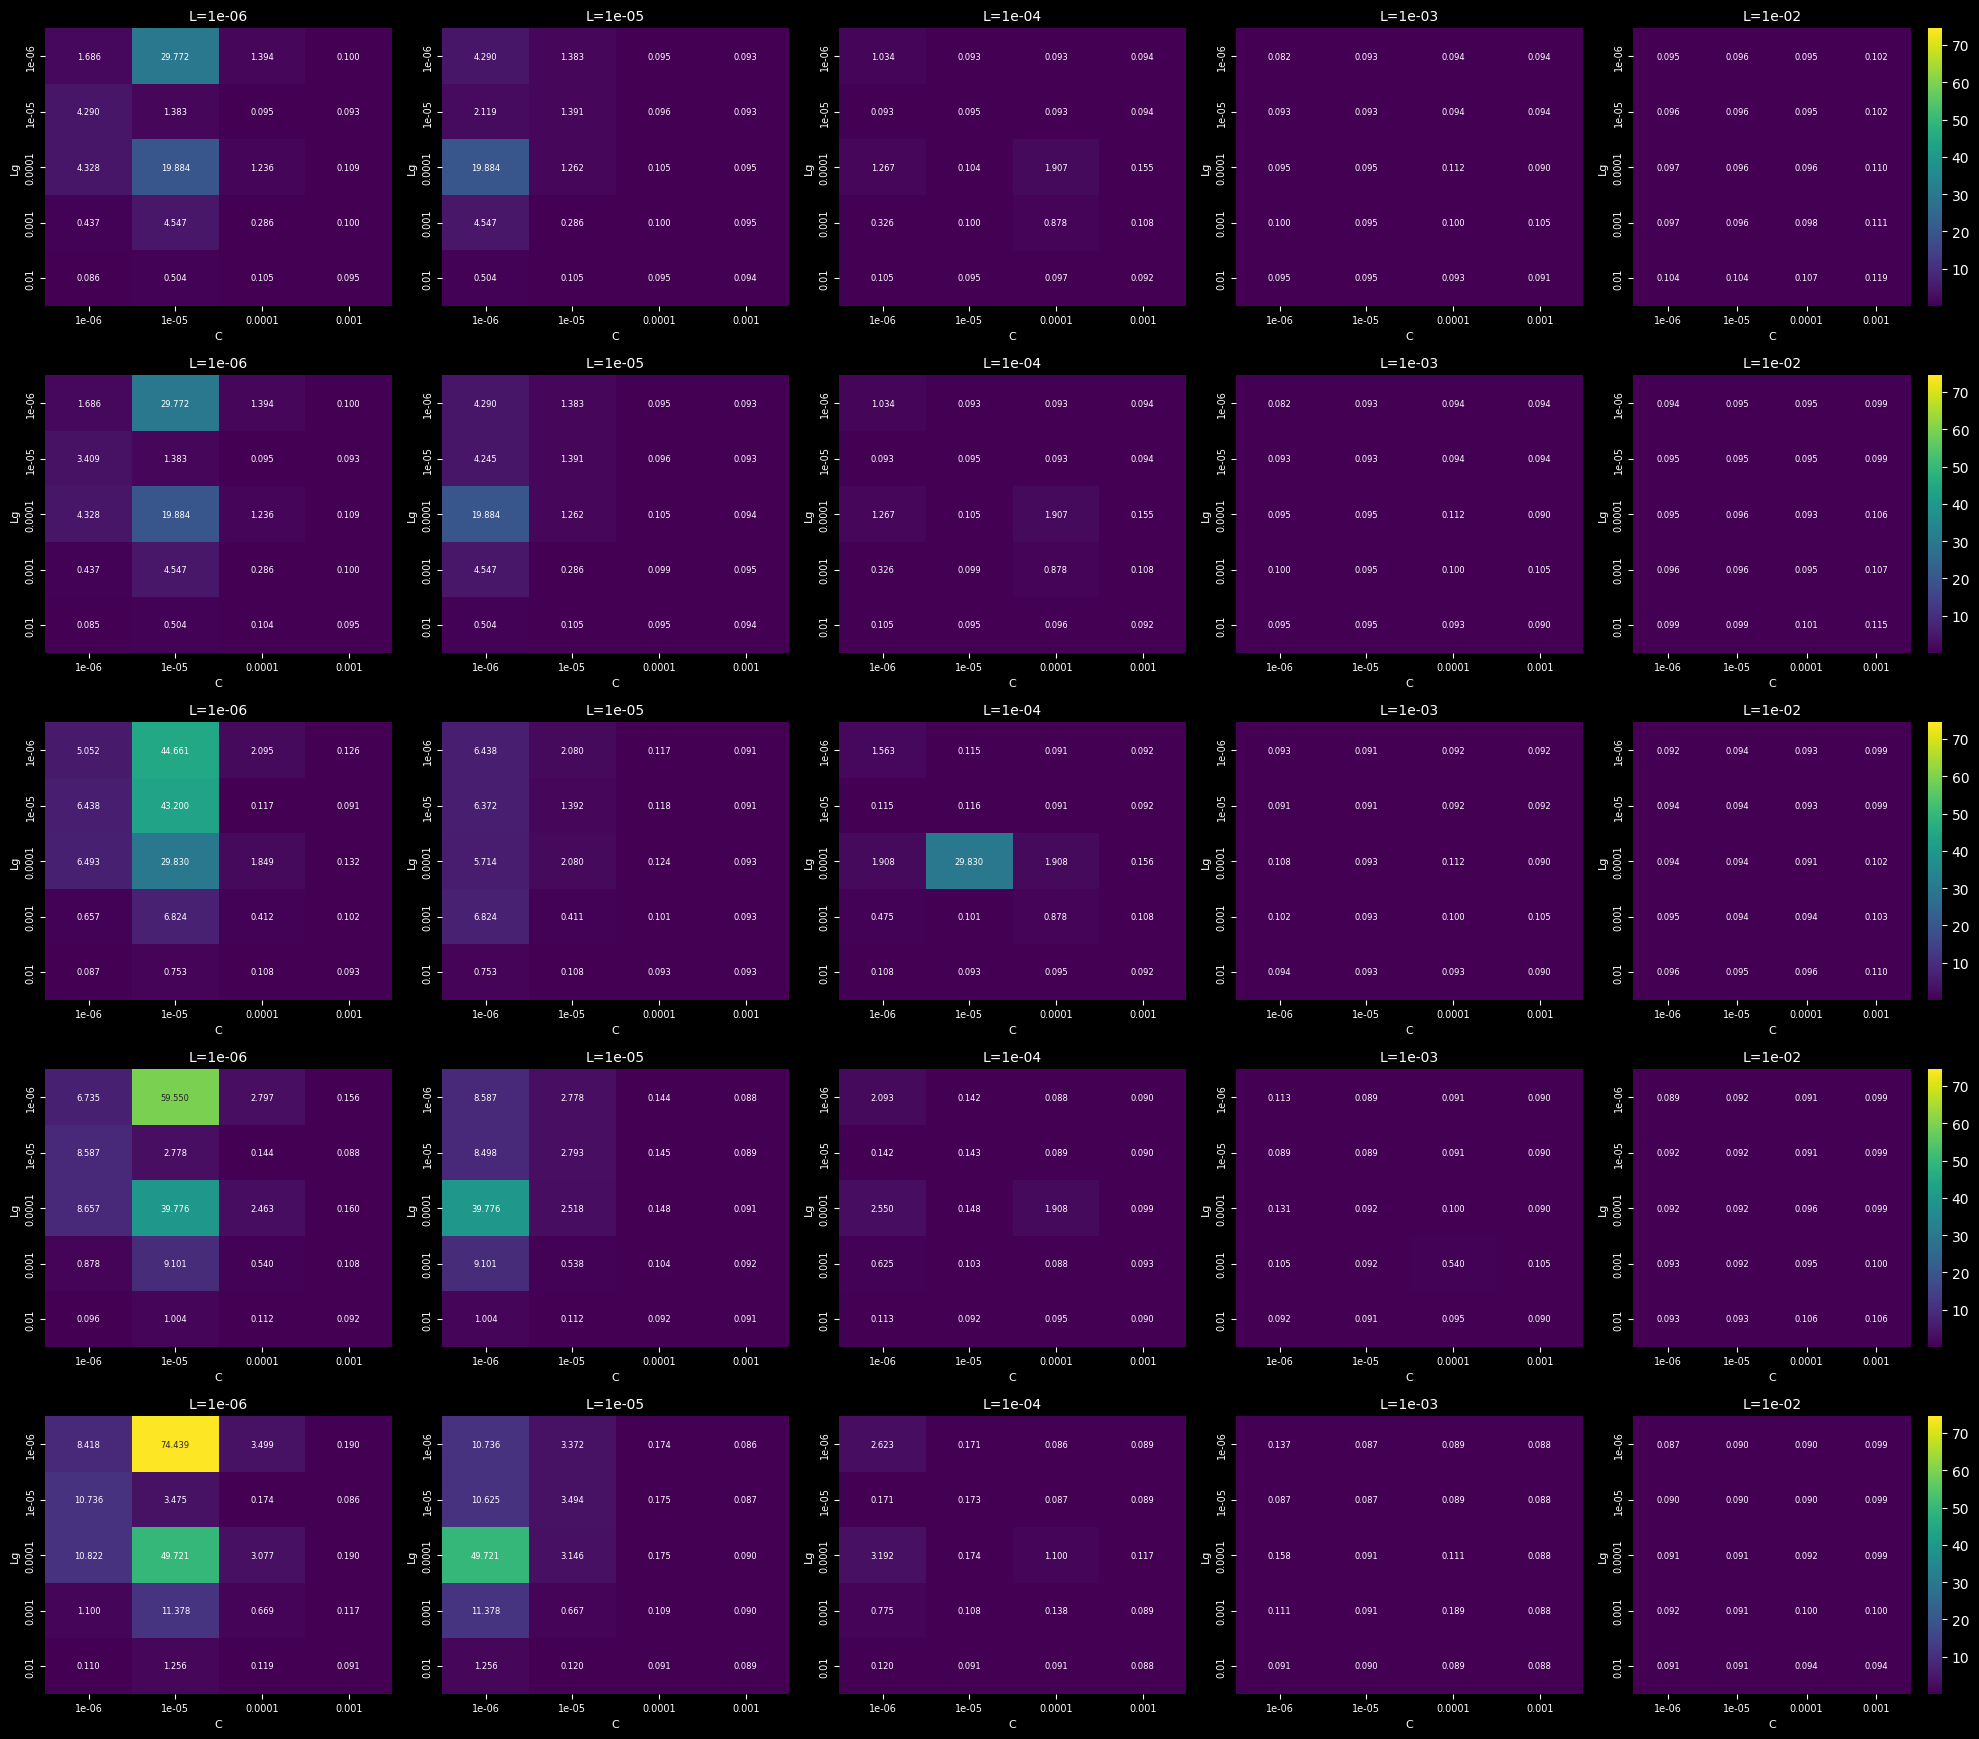

ValueError: Nema podataka za Time step = 7e-06

In [ ]:
draw_merged_heatmaps_by_Vin(df=results_df, metrics=["MAE"], time_step_filter = 5.000000e-07)
draw_merged_heatmaps_by_Vin(df=results_df, metrics=["MAE"], time_step_filter = 2.000000e-06)
draw_merged_heatmaps_by_Vin(df=results_df, metrics=["MAE"], time_step_filter = 5.000000e-06)
'''draw_merged_heatmaps_by_Vin(df=results_df, metrics=["MAE"], time_step_filter = 7.000000e-06)
draw_merged_heatmaps_by_Vin(df=results_df, metrics=["MAE"], time_step_filter = 1.000000e-05)'''

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd

def draw_merged_heatmaps(df, metrics=["MAE", "MARE", "MAXRE"], output_file="merged_heatmaps.png"):
    df = pd.DataFrame(df)
    L_vals = sorted(df["L"].unique())

    fig, axes = plt.subplots(len(metrics), len(L_vals), figsize=(4 * len(L_vals), 4 * len(metrics)))
    if len(metrics) == 1:
        axes = np.expand_dims(axes, axis=0)
    if len(L_vals) == 1:
        axes = np.expand_dims(axes, axis=1)

    cmap = "viridis"

    for row_idx, metric in enumerate(metrics):
        vmin = df[metric].min()
        vmax = df[metric].max()

        for col_idx, L_val in enumerate(L_vals):
            ax = axes[row_idx][col_idx]
            subset = df[df["L"] == L_val]
            pivot = subset.pivot(index="Lg", columns="C", values=metric)

            sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap,
                        cbar=(col_idx == len(L_vals) - 1), ax=ax,
                        vmin=vmin, vmax=vmax, annot_kws={"size": 6})
            
            if row_idx == 0:
                ax.set_title(f"L={L_val:.0e}", fontsize=10)
            if col_idx == 0:
                ax.set_ylabel(f"{metric}", fontsize=10)
            else:
                ax.set_ylabel("")
            ax.set_xlabel("")

    for ax in axes.flat:
        ax.set_xlabel("C", fontsize=8)
        ax.set_ylabel("Lg", fontsize=8)
        ax.tick_params(axis='both', labelsize=7)

    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    print(f"✅ Saved: {output_file}")
    plt.show()

draw_merged_heatmaps(ress, output_file="L_heatmaps_all_metrics.png")


In [ ]:
import torch
import pandas as pd
import numpy as np
import re
import random

def evaluate_model_on_csv(
    model_path, model_class, file_list, sample_duration=0.01,
    input_size=8, hidden_layers=10, neurons_per_layer=96, output_size=1
):
    results = []

    print(f"📦 Loading model: {model_path}")
    model = model_class(
        input_size=input_size,
        hidden_layers=hidden_layers,
        neurons_per_layer=neurons_per_layer,
        output_size=output_size
    ).to(device)

    model.load_state_dict(torch.load(model_path))
    model.eval()
    print("✅ Model loaded and ready.\n")

    for file_idx, file in enumerate(file_list):
        print(f"📄 [{file_idx + 1}/{len(file_list)}] Evaluating: {file}")

        # Extract parameters from filename
        basename = file.rsplit(".", 1)[0]
        pattern = r"L=(?P<L>[\deE\.\-]+)_C=(?P<C>[\deE\.\-]+)_Lg=(?P<Lg>[\deE\.\-]+)__time_step_(?P<time_step>[\deE\.\-]+)"
        match = re.search(pattern, basename)

        if not match:
            print(f"⛔️ Cannot parse parameters from: {file}")
            continue

        try:
            L = float(match["L"])
            C = float(match["C"])
            Lg = float(match["Lg"])
            time_step = float(match["time_step"])
        except Exception as e:
            print(f"❌ Error parsing parameters: {e}")
            continue

        # Load CSV
        try:
            df = pd.read_csv(file)
        except Exception as e:
            print(f"❌ Error reading file: {e}")
            continue

        n_steps = int(sample_duration / time_step)
        if len(df) < n_steps + 1:
            print(f"⚠️ Skipping: not enough data for {sample_duration}s window.")
            continue

        start_idx = random.randint(0, len(df) - n_steps - 1)
        sample = df.iloc[start_idx:start_idx + n_steps]

        for phase in ["A", "B", "C"]:
            try:
                I = sample[f"I{phase.lower()}"].values
                top = (sample[f"top{phase}"] > 0.5).astype(float)
                bot = (sample[f"bot{phase}"] > 0.5).astype(float)
                L_val = sample[f"L{phase.lower()}_value"].values
                C_val = sample[f"C{phase.lower()}_value"].values
                Lg_val = sample[f"L{phase.lower()}g_value"].values
                dt = sample["time_step"].values
                next_I = df[f"I{phase.lower()}_next_value"].iloc[start_idx:start_idx + n_steps].values

                inputs_np = np.stack([I, top, bot, L_val, C_val, Lg_val, dt], axis=1)
                inputs = torch.tensor(inputs_np, dtype=torch.float32).to(device)
                targets = torch.tensor(next_I, dtype=torch.float32).to(device)

                with torch.no_grad():
                    preds = model(inputs).squeeze()

                mse = torch.mean(-np.abs(preds - targets)).item()

                print(f"  ✅ Phase {phase} | MAE: {mse:.3e} | L = {L:.1e} | C = {C:.1e} | Lg = {Lg:.1e}")

                results.append({
                    "L": L,
                    "C": C,
                    "Lg": Lg,
                    "time_step": time_step,
                    "phase": phase,
                    "MAE": mse
                })

            except Exception as e:
                print(f"  ⚠️ Failed on phase {phase}: {e}")
                continue

        print()

    print("🎯 Evaluation complete.")
    return pd.DataFrame(results)


In [ ]:
df_results = evaluate_model_on_csv(
    model_path="1ph_inv_model_LCL_h10w96_variable_step.pth",
    model_class=FeedforwardNet,
    file_list=wanted_files,
    sample_duration=0.01,
    input_size=8,
    hidden_layers=10,
    neurons_per_layer=96,
    output_size=output_size
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_scatter_mae(df, value_col="MAE", threshold=None, verbose=True):
    original_len = len(df)

    if threshold is not None:
        filtered_out = df[df[value_col] > threshold]
        df = df[df[value_col] <= threshold]
        print(f"📉 Filtrirano: {len(df)} zadržano / {len(filtered_out)} izbačeno (>{threshold})")

        if verbose and not filtered_out.empty:
            print("\n🗑️ Odbačeni uzorci:")
            for i, row in filtered_out.iterrows():
                print(f"  ✖ phase={row['phase']} | L={row['L']:.2e}, C={row['C']:.2e}, Lg={row['Lg']:.2e} | {value_col}={row[value_col]:.2e}")
            print()

    print("🎯 Broj unikatnih vrednosti:")
    print("  Lg:", df["Lg"].nunique())
    print("  C :", df["C"].nunique())
    print("  L :", df["L"].nunique())

    min_val = df[value_col].min()
    max_val = df[value_col].max()
    norm = mcolors.Normalize(vmin=min_val, vmax=max_val)
    cmap = plt.colormaps.get_cmap("cividis")

    colors = cmap(norm(df[value_col].values))

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    sc = ax.scatter(df["Lg"], df["C"], df["L"],
                    c=colors, s=50, edgecolor="k", alpha=0.9)

    ax.set_xlabel("Lg", fontsize=12)
    ax.set_ylabel("C", fontsize=12)
    ax.set_zlabel("L", fontsize=12)
    ax.set_title(f"3D Scatter: {value_col} by L, C, Lg", fontsize=14)

    mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.6, aspect=20, pad=0.1)
    cbar.set_label(value_col, fontsize=12)

    plt.tight_layout()
    plt.show()


plot_3d_scatter_mae(df_results, value_col="MAE", threshold=1, verbose=True)


In [ ]:
import plotly.graph_objs as go
import pandas as pd

def plot_3d_scatter_mae_interactive(df, value_col="MSE", threshold=None, verbose=True):
    if threshold is not None:
        filtered_out = df[df[value_col] > threshold]
        df = df[df[value_col] <= threshold]
        print(f"📉 Filtrirano: {len(df)} zadržano / {len(filtered_out)} izbačeno (>{threshold})")

        if verbose and not filtered_out.empty:
            print("\n🗑️ Odbačeni uzorci:")
            for i, row in filtered_out.iterrows():
                print(f"  ✖ phase={row['phase']} | L={row['L']:.2e}, C={row['C']:.2e}, Lg={row['Lg']:.2e} | {value_col}={row[value_col]:.2e}")
            print()

    print("🎯 Broj unikatnih vrednosti:")
    print("  Lg:", df["Lg"].nunique())
    print("  C :", df["C"].nunique())
    print("  L :", df["L"].nunique())

    fig = go.Figure(data=[
        go.Scatter3d(
            x=df["Lg"], y=df["C"], z=df["L"],
            mode="markers",
            marker=dict(
                size=6,
                color=df[value_col],
                colorscale="Cividis",
                colorbar=dict(title=value_col),
                opacity=0.9
            ),
            text=[f"Phase: {p}<br>MAE: {m:.3e}" for p, m in zip(df["phase"], df[value_col])]
        )
    ])

    fig.update_layout(
        scene=dict(
            xaxis_title="Lg",
            yaxis_title="C",
            zaxis_title="L"
        ),
        title=f"Interactive 3D Scatter: {value_col} by L, C, Lg",
        margin=dict(l=0, r=0, b=0, t=30)
    )

    fig.show()


plot_3d_scatter_mae_interactive(df_results, value_col="MAE", threshold=1)



In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error

def recursive_rolling_mean(arr, window=250, threshold=1e-9, max_iters=1000):
    """
    Rekurzivno primenjuje rolling mean dok MAE između dva uzastopna
    smirena rezultata ne padne ispod zadatog praga.
    """
    prev = arr.copy()
    for i in range(max_iters):
        smoothed = np.convolve(prev, np.ones(window)/window, mode='same')
        mae = mean_absolute_error(prev, smoothed)
        if mae < threshold:
           # print(f"✅ Stopped at iteration {i+1} (MAE={mae:.6f})")
            return smoothed
        prev = smoothed
   # print(f"⚠️ Max iterations reached ({max_iters}), final MAE={mae:.6f}")
    return smoothed


In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import re

def rolling_mean(arr, window=200):
    return np.convolve(arr, np.ones(window) / window, mode='same')

def plot_prediction_vs_truth_1model_multi_phase_recursive(
    csv_path,
    model,
    name,
    scaler_X,
    scaler_y,
    hidden_layers,
    neurons_per_layer,
    start_time,
    end_time,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    phases_to_display=[0, 1, 2],
    smooth=True,
    window_size=200,
    save_path="prediction_vs_truth_highres.png"
):
    model.load_state_dict(torch.load(name, map_location=device))
    model.to(device)
    model.eval()

    L_val = C_val = Lg_val = None
    param_text = None

    match = re.search(r"L=(?P<L>[\deE\-\+\.]+).*?C=(?P<C>[\deE\-\+\.]+).*?Lg=(?P<Lg>[\deE\-\+\.]+)", csv_path)
    if match:
        L_val = float(match.group("L"))
        C_val = float(match.group("C"))
        Lg_val = float(match.group("Lg"))
        print("✅ Parsed from:", csv_path)
        print("🧪 Extracted values:", f"L={L_val}, C={C_val}, Lg={Lg_val}")
        param_text = f"L={L_val:.0e}  C={C_val:.0e}   Lg={Lg_val:.0e}"

    df = pd.read_csv(csv_path)

    inputs_per_phase = {
        0: df[['Ia', 'topA', 'botA', 'time_step', "La_value", "Ca_value", "Lag_value", ]].values.astype(np.float32),
        1: df[['Ib', 'topB', 'botB', 'time_step', "Lb_value", "Cb_value", "Lbg_value"]].values.astype(np.float32),
        2: df[['Ic', 'topC', 'botC', 'time_step', "Lc_value", "Cc_value", "Lcg_value"]].values.astype(np.float32),
    }

    targets = df[['Ia_next_value', 'Ib_next_value', 'Ic_next_value']].values.astype(np.float32)
    next_time = df["time"].values + df["time_step"].values

    preds = []
    for i in phases_to_display:
        X = inputs_per_phase[i]
        X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
        with torch.no_grad():
            y_pred = model(X_tensor).cpu().numpy()
        preds.append(y_pred)

    y_pred_all = np.concatenate(preds, axis=1)
    y_true_all = targets

    mask = (next_time >= start_time) & (next_time <= end_time)
    plt.style.use("dark_background")
    fig, ax1 = plt.subplots(figsize=(16, 8))
    phase_colors = ["teal", "darkorange", "seagreen"]
    truth_colors = ["indigo", "firebrick", "hotpink"]

    mae_texts = []
    for idx, phase in enumerate(phases_to_display):
        true_vals = y_true_all[mask, phase]
        pred_vals = y_pred_all[mask, idx]
        mae = mean_absolute_error(true_vals, pred_vals)
        mae_texts.append(f"I{chr(97 + phase)}={mae:.4f}")

        ax1.plot(next_time[mask], true_vals, color=phase_colors[phase], alpha = 0.6, linewidth=2.7)

    for idx, phase in enumerate(phases_to_display):
        true_vals = y_true_all[mask, phase]
        pred_vals = y_pred_all[mask, idx]
        mae = mean_absolute_error(true_vals, pred_vals)
        mae_texts.append(f"I{chr(97 + phase)}={mae:.4f}")

        ax1.plot(next_time[mask], pred_vals, color=phase_colors[phase], linewidth=1.3, alpha = 0.6, linestyle='--')
        
    for idx, phase in enumerate(phases_to_display):
        true_vals = y_true_all[mask, phase]
        pred_vals = y_pred_all[mask, idx]
        mae = mean_absolute_error(true_vals, pred_vals)
        mae_texts.append(f"I{chr(97 + phase)}={mae:.4f}")

        if smooth:
            true_vals = recursive_rolling_mean(true_vals, window=window_size)
            pred_vals = recursive_rolling_mean(pred_vals, window=window_size)

        ax1.plot(next_time[mask], true_vals, color=phase_colors[phase], alpha=1, linewidth=0.7, label=f"True Phase {phase+1}")

    for idx, phase in enumerate(phases_to_display):
        true_vals = y_true_all[mask, phase]
        pred_vals = y_pred_all[mask, idx]
        mae = mean_absolute_error(true_vals, pred_vals)
        mae_texts.append(f"I{chr(97 + phase)}={mae:.4f}")

        if smooth:
            true_vals = recursive_rolling_mean(true_vals, window=window_size)
            pred_vals = recursive_rolling_mean(pred_vals, window=window_size)

        ax1.plot(next_time[mask], pred_vals, color=phase_colors[phase], linestyle='--', linewidth=2, label=f"Pred {phase + 1}")


    ax1.set_xlabel("Time (s)", fontsize=14)
    ax1.set_ylabel("Current (A)", fontsize=14)
    ax1.grid(True)

    ax2 = ax1.twinx()
    for idx, phase in enumerate(phases_to_display):
        err = -np.abs(y_true_all[mask, phase] - y_pred_all[mask, idx])
        if smooth:
            err = recursive_rolling_mean(err, window=window_size)
        ax2.plot(next_time[mask], err, color=phase_colors[phase], linestyle="--", linewidth=1, alpha=1, label=f"Error {phase + 1}")

    ax2.set_ylabel("−|Error| (A)", color='gray', fontsize=14)

    title = f"Prediction per phase vs GT | \n MAE: {', '.join(mae_texts)}  \n {param_text}"
    plt.title(title, fontsize=16)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower center", ncol=3, fontsize=11)
    plt.style.use("dark_background")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"✅ Saved high-res figure to: {save_path}")
    plt.show()


In [ ]:
file_names = ["new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-07.csv",
              "new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=5e+02_time_step_2e-06.csv",
              "new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=5e+02_time_step_5e-06.csv",
              "new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=5e+02_time_step_7e-06.csv",
              "new_3ph_inv_L=1e-04_C=1e-04_Lg=1e-06_V=5e+02_time_step_1e-05.csv",              
              ]
hidden_layers = 9
neurons_per_layer = 96
for f in file_names:
    plot_prediction_vs_truth_1model_multi_phase(
        csv_path=f, 
        model=FeedforwardNet(hidden_layers=hidden_layers, neurons_per_layer=neurons_per_layer, input_size=8),
        name="1ph_inv_model_LCL_h9w96_variable_input_small_patch.pth",
        scaler_X=dataset.scaler_X,
        scaler_y=dataset.scaler_y,
        hidden_layers=hidden_layers,
        neurons_per_layer=neurons_per_layer,
        start_time=0.01,
        end_time=0.02,
        smooth=False,
        window_size=50,
        phases_to_display=[0, 1, 2],
        save_path=""
    )

    '''plot_prediction_vs_truth_1model_multi_phase_recursive(
        csv_path=f,
        model=FeedforwardNet(hidden_layers=9, neurons_per_layer=64),
        name=f"1ph_inv_model_LCL_h{hidden_layers}w{neurons_per_layer}_variable_input_small_patch.pth",
        scaler_X=dataset.scaler_X,
        scaler_y=dataset.scaler_y,
        hidden_layers=hidden_layers,
        neurons_per_layer=neurons_per_layer,
        start_time=0.01,
        end_time=0.02,
        smooth=True,
        window_size=50,
        phases_to_display=[0, 1, 2],
        save_path="     "
    )'''